# QUESTION 1

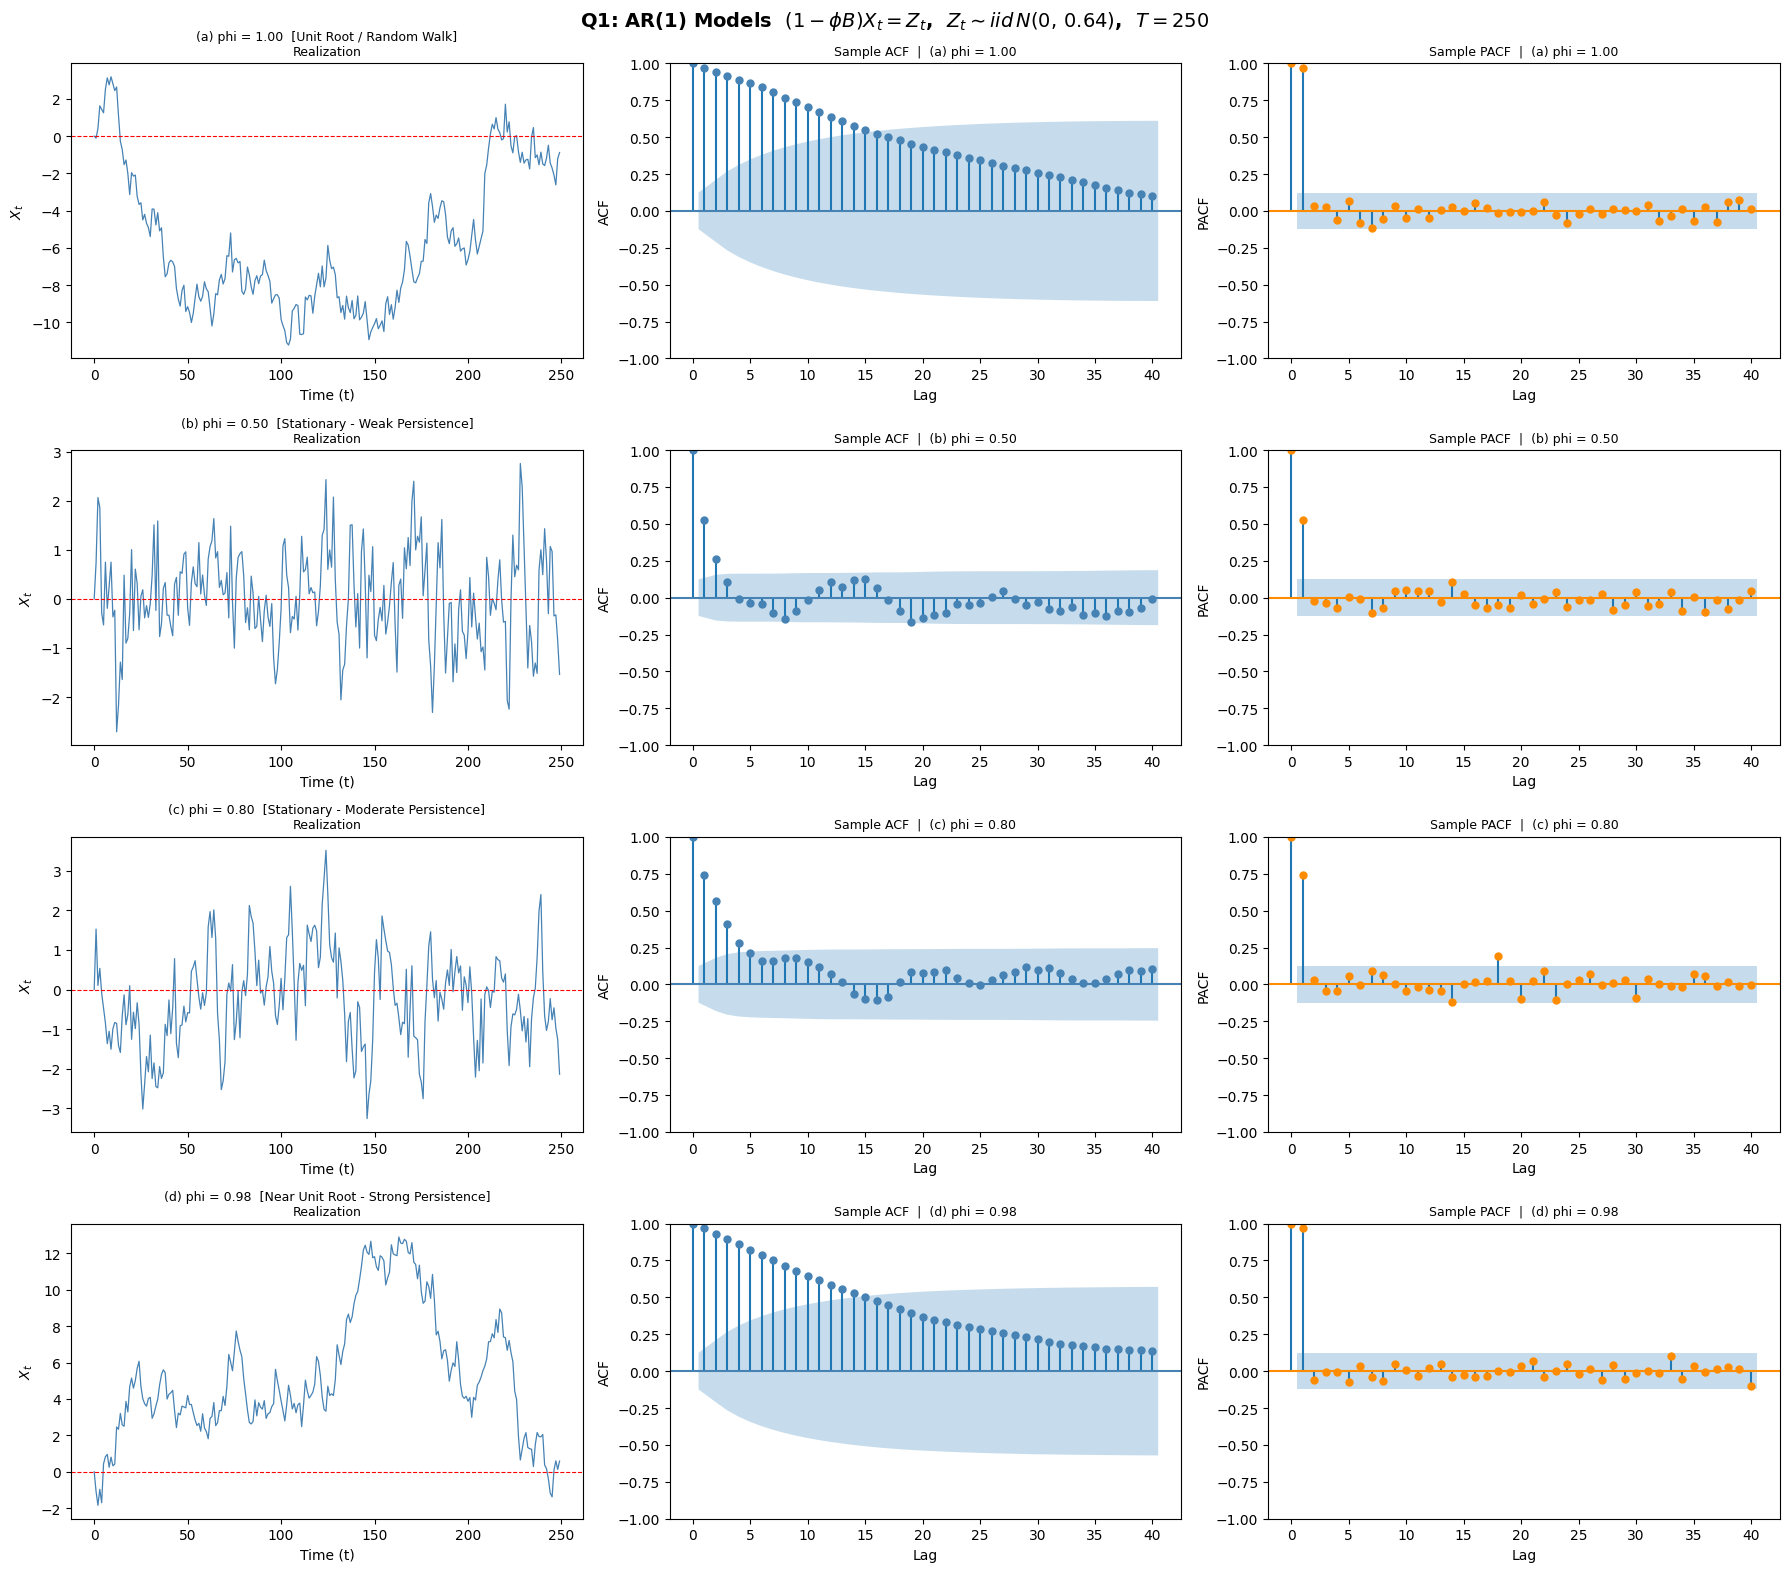

Done! Plot saved as Q1_AR1_plots.png


In [ ]:
"""
Assignment 2 - Question 1
"""

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(42)

T = 250
sigma = np.sqrt(0.64)   # = 0.8


models = [
    (1.00, "(a) phi = 1.00  [Unit Root / Random Walk]"),
    (0.50, "(b) phi = 0.50  [Stationary - Weak Persistence]"),
    (0.80, "(c) phi = 0.80  [Stationary - Moderate Persistence]"),
    (0.98, "(d) phi = 0.98  [Near Unit Root - Strong Persistence]"),
]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.suptitle(
    r"Q1: AR(1) Models  $(1 - \phi B)X_t = Z_t$,  $Z_t \sim iid\,N(0,\,0.64)$,  $T = 250$",
    fontsize=14, fontweight='bold'
)

for i, (phi, label) in enumerate(models):

    #simulating AR(1)
    Z = np.random.normal(0, sigma, T)
    X = np.zeros(T)
    for t in range(1, T):
        X[t] = phi * X[t-1] + Z[t]

    # plot 1: realization
    axes[i, 0].plot(range(T), X, color='steelblue', linewidth=0.9)
    axes[i, 0].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[i, 0].set_title(f"{label}\nRealization", fontsize=9)
    axes[i, 0].set_xlabel("Time (t)")
    axes[i, 0].set_ylabel("$X_t$")

    # plot 2: Sample ACF
    plot_acf(X, lags=40, ax=axes[i, 1], alpha=0.05, color='steelblue')
    axes[i, 1].set_title(f"Sample ACF  |  {label.split('[')[0].strip()}", fontsize=9)
    axes[i, 1].set_xlabel("Lag")
    axes[i, 1].set_ylabel("ACF")

    # plot 3: Sample PACF
    plot_pacf(X, lags=40, ax=axes[i, 2], method='ywm', alpha=0.05, color='darkorange')
    axes[i, 2].set_title(f"Sample PACF  |  {label.split('[')[0].strip()}", fontsize=9)
    axes[i, 2].set_xlabel("Lag")
    axes[i, 2].set_ylabel("PACF")

plt.tight_layout()
plt.savefig("Q1_AR1_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done! Plot saved as Q1_AR1_plots.png")


***

### Part 1: Description of Model Behavior

The general AR(1) model is defined as $(1 - \phi B)X_t = Z_t$, where $Z_t \sim iidNormal(0, 0.64)$[cite: 5]. The behavior of the time series changes drastically depending on the autoregressive coefficient, $\phi$.

**(a) $\phi = 1.00$: $(1 - B)X_t = Z_t$** [cite: 9]
* **Realization:** This represents a Random Walk, which is a non-stationary process. The plot shows the series wandering persistently without reverting to a constant mean, and its variance increases over time.
* **Sample ACF:** The autocorrelations decay extremely slowly (almost linearly). This failure to drop off quickly to zero is the classic signature of a non-stationary, unit-root process.
* **Sample PACF:** There is a single significant spike at lag 1 with a value of exactly $1.0$. All subsequent lags fall abruptly within the blue confidence band, confirming the AR(1) structure.

**(b) $\phi = 0.50$: $(1 - 0.5B)X_t = Z_t$**
* **Realization:** The series is strictly stationary. It fluctuates rapidly around a constant mean of zero, showing weak persistence and short memory.
* **Sample ACF:** The autocorrelations decay exponentially and very rapidly toward zero, indicating that past values quickly lose their influence on future values.
* **Sample PACF:** There is a sharp cut-off after lag 1, with the spike having a value of approximately $0.5$ (matching the $\phi$ coefficient).

**(c) $\phi = 0.80$: $(1 - 0.8B)X_t = Z_t$**
* **Realization:** The series is stationary but exhibits moderate persistence. The data shows visual "clustering" where positive values tend to follow positive values, but it still consistently reverts to the mean of zero.
* **Sample ACF:** The geometric decay is still present but noticeably slower than when $\phi = 0.50$. The "memory" of the series lasts longer.
* **Sample PACF:** Sharp cut-off after lag 1, with the spike corresponding to the coefficient $0.8$.

**(d) $\phi = 0.98$: $(1 - 0.98B)X_t = Z_t$**
* **Realization:** The series is highly persistent and visually mimics a random walk over finite samples. While technically stationary (since $|\phi| < 1$), it takes a very long time to revert to the mean.
* **Sample ACF:** The decay is incredibly slow and persistent, closely resembling the non-stationary case in plot (a).
* **Sample PACF:** Sharp cut-off after lag 1, with the spike very close to $1.0$ ($0.98$).

---

###  When Roots Approaches and On the Unit Circle

The characteristic equation for an AR(1) model is:
$$1 - \phi z = 0 \implies z = \frac{1}{\phi}$$

For an AR process to be causal and stationary, the roots of the characteristic equation must lie strictly *outside* the unit circle (i.e., $|z| > 1$, which implies $|\phi| < 1$).The plots clearly illustrate how the behavior changes based on the root's location:

**When the root approaches the unit circle (Moving from $\phi = 0.50$ to $0.80$ to $0.98$):**
As $\phi$ increases towards $1$, the root $z$ moves closer to the unit circle boundary. This causes the series to exhibit much stronger memory, and the variance of the series increases ($\frac{\sigma^2}{1-\phi^2}$). The sample ACF reflects this by decaying much more slowly—shifting from a rapid exponential drop-off to a near-flat decline. The PACF at lag 1 mathematically approaches $1.0$.

**When the root is ON the unit circle ($\phi = 1.00$):**
When the root sits exactly on the unit circle ($z = 1$), the process entirely loses its mean-reverting property and becomes a non-stationary random walk. Shocks to the system now have a permanent effect rather than a transitory one. The theoretical variance becomes infinite, and the ACF fundamentally fails to decay to zero. While the PACF still identifies the AR(1) structure with a single spike at $1.0$, the underlying assumptions of stationarity are broken.

---

# QUESTION 2

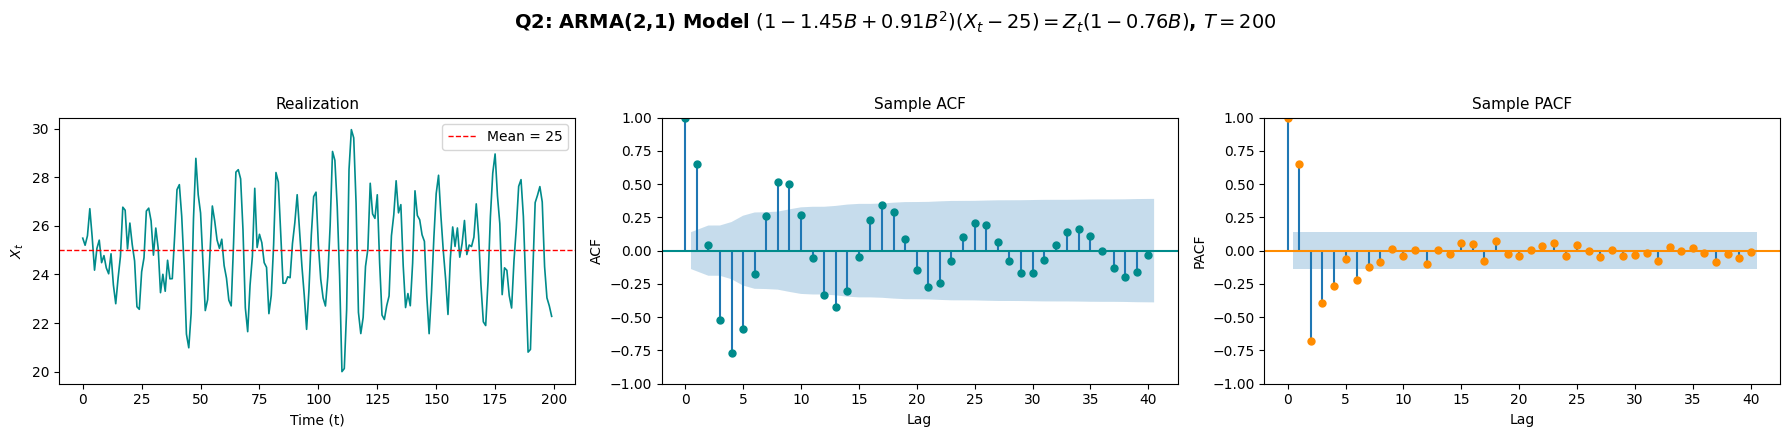

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


np.random.seed(42)


T = 200

# AR polynomial: 1 - 1.45B + 0.91B^2
ar = np.array([1, -1.45, 0.91])

# MA polynomial: 1 - 0.76B
ma = np.array([1, -0.76])

# Generate zero-mean ARMA(2,1) process Y_t = X_t - 25
Y = arma_generate_sample(ar=ar, ma=ma, nsample=T, scale=1.0)

# Add the mean back to get X_t
X = Y + 25

# Plotting setup - Unpacking directly into ax1, ax2, ax3
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle(r"Q2: ARMA(2,1) Model $(1 - 1.45B + 0.91B^2)(X_t - 25) = Z_t(1 - 0.76B)$, $T = 200$",
             fontsize=14, fontweight='bold', y=1.08)

# 1. Realization Plot
ax1.plot(range(T), X, color='darkcyan', linewidth=1.2)
ax1.axhline(25, color='red', linestyle='--', linewidth=1, label="Mean = 25")
ax1.set_title("Realization", fontsize=11)
ax1.set_xlabel("Time (t)")
ax1.set_ylabel("$X_t$")
ax1.legend()

# 2. Sample ACF Plot
plot_acf(X, lags=40, ax=ax2, alpha=0.05, color='darkcyan')
ax2.set_title("Sample ACF", fontsize=11)
ax2.set_xlabel("Lag")
ax2.set_ylabel("ACF")

# 3. Sample PACF Plot
plot_pacf(X, lags=40, ax=ax3, method='ywm', alpha=0.05, color='darkorange')
ax3.set_title("Sample PACF", fontsize=11)
ax3.set_xlabel("Lag")
ax3.set_ylabel("PACF")

plt.tight_layout()
plt.savefig("Q2_ARMA21_plot.png", dpi=150, bbox_inches='tight')
plt.show()

### Question 2: ARMA(2,1) Model Analysis

**Model Specification:**
The simulated model is an ARMA(2,1) process given by the equation:
$$(1 - 1.45B + 0.91B^2)(X_t - 25) = Z_t(1 - 0.76B)$$
where $Z_t \sim \text{iid } N(0, 1)$ and $T = 200$.

**1. Model Characteristics & Roots**
* **Mean:** The term $(X_t - 25)$ indicates that the series is not zero-mean. Instead, it fluctuates around a constant theoretical mean of $\mu = 25$.
* **Stationarity (AR Roots):** To determine the stationarity and behavioral characteristics of the series, we examine the characteristic equation of the autoregressive polynomial:
  $$1 - 1.45z + 0.91z^2 = 0$$
  Solving for $z$, we find complex conjugate roots at $z \approx 0.796 \pm 0.684i$. The magnitude of these roots is $|z| \approx 1.048$. Because the magnitude is strictly greater than $1$ (the roots lie outside the unit circle), the process is **stationary**. Furthermore, the presence of complex roots dictates that the time series will exhibit pseudo-periodic (cyclical) behavior rather than simple exponential decay.
* **Invertibility (MA Roots):** The moving average polynomial is $1 - 0.76z = 0$, which yields a single root at $z \approx 1.316$. Since this root is strictly greater than $1$ (outside the unit circle), the process is **invertible**.

**2. Realization Plot**
The time series realization plot visually confirms the theoretical properties. The data consistently fluctuates around the theoretical mean of $25$. More notably, the series exhibits a distinct "wavy" or cyclical pattern. This pseudo-periodic oscillation is the direct visual manifestation of the complex roots found in the AR polynomial, distinguishing it from the more erratic, jagged behavior of models with only real roots.

**3. Sample ACF and PACF Plots**
For a mixed ARMA(p,q) process, theory states that neither the Autocorrelation Function (ACF) nor the Partial Autocorrelation Function (PACF) will cut off abruptly; both will tail off.
* **Sample ACF:** The sample ACF displays a classic **damped sinusoidal wave** pattern. It oscillates between positive and negative values, gradually shrinking in amplitude as the lag increases until it fades into the significance bands. This oscillatory decay is the hallmark signature of an AR process with complex roots.
* **Sample PACF:** The sample PACF also tails off rather than cutting off sharply after a specific lag. It begins with significant spikes (notably at lags 1, 2, and 4) and exhibits its own damped oscillatory decay. The fact that both functions tail off confirms the presence of both autoregressive and moving average components in the underlying data generating process.

---

# QUESTION 3

AR roots: [-1.28858557 -0.88186898]
AR moduli: [1.28858557 0.88186898]
Causal: False

MA roots: [-0.19230769+1.22534864j -0.19230769-1.22534864j]
MA moduli: [1.24034735 1.24034735]
Invertible: True


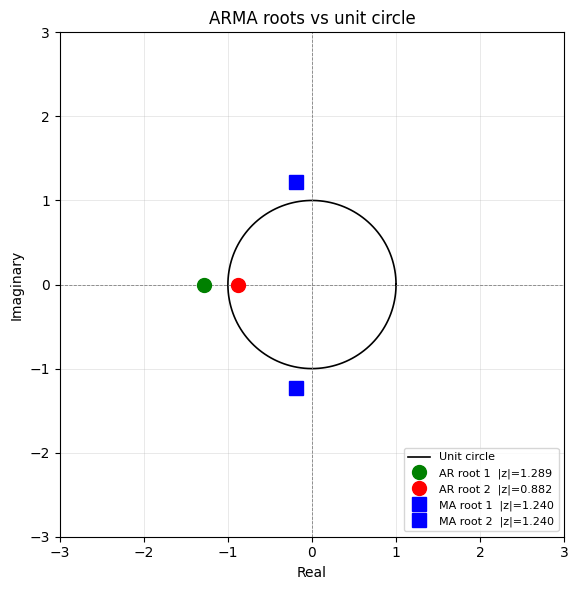

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# given : ARMA model: Yt + 1.91Yt-1 + 0.88Yt-2 = Zt + 0.25Zt-1 + 0.65Zt-2
# phi(z)   = 1 + 1.91z + 0.88z^2
# theta(z) = 1 + 0.25z + 0.65z^2

ar_roots = np.roots([0.88, 1.91, 1.0])
ma_roots = np.roots([0.65, 0.25, 1.0])

print("AR roots:", ar_roots)
print("AR moduli:", np.abs(ar_roots))
print("Causal:", np.all(np.abs(ar_roots) > 1))

print("\nMA roots:", ma_roots)
print("MA moduli:", np.abs(ma_roots))
print("Invertible:", np.all(np.abs(ma_roots) > 1))

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')

t = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(t), np.sin(t), 'k-', lw=1.2, label='Unit circle')

ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.axvline(0, color='gray', lw=0.6, ls='--')

# AR roots: green if outside, red if inside
for i, root in enumerate(ar_roots, 1):
    color = 'green' if abs(root) > 1 else 'red'
    ax.plot(root.real, root.imag, 'o', color=color, ms=10,
            label=f'AR root {i}  |z|={abs(root):.3f}')

# MA roots: blue if outside, red if inside
for i, root in enumerate(ma_roots, 1):
    color = 'blue' if abs(root) > 1 else 'red'
    ax.plot(root.real, root.imag, 's', color=color, ms=10,
            label=f'MA root {i}  |z|={abs(root):.3f}')

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xlabel('Real')
ax.set_ylabel('Imaginary')
ax.set_title('ARMA roots vs unit circle')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, lw=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig('arma_roots.png', dpi=150, bbox_inches='tight')
plt.show()

**Causality**

The process is not causal and the issue comes from the AR part.

For an ARMA model to be causal, all the roots of the AR polynomial
ϕ(z) = 1 + 1.91z + 0.88z^2 need to lie outside the unit circle (that means have modulus greater than 1).

When we solve this, we get two roots:
- One at about -1.29 : modulus > 1
- One at about -0.88 : modulus < 1

Because that second root lies inside the unit circle, the process can’t be written purely in terms of past and present noise. Instead, it would depend on future values of the noise, which violates causality.

**Invertibility**

The process is invertible, and here the MA part behaves nicely.
For invertibility, we check the roots of the MA polynomial
θ(z) = 1 + 0.25z + 0.65z^2

The roots here are complex:
- Approximately -0.19 ± 1.23i,
- Both have modulus ≈ 1.24 > 1

Since both roots lie outside the unit circle, we can express the noise Zt
​in terms of past and present values of Yt.

That’s exactly what invertibility means.

---

# QUESTION 4

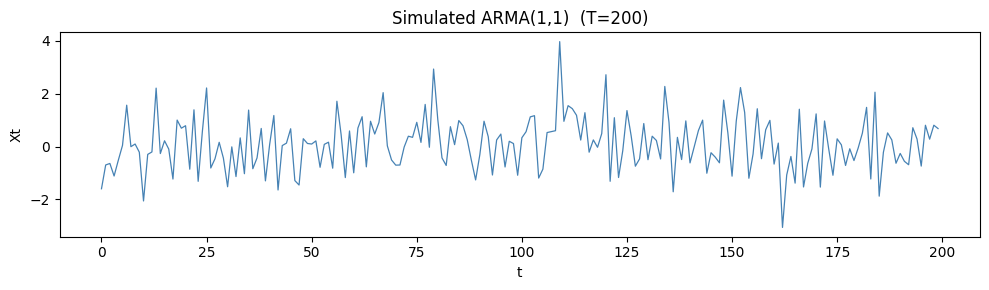

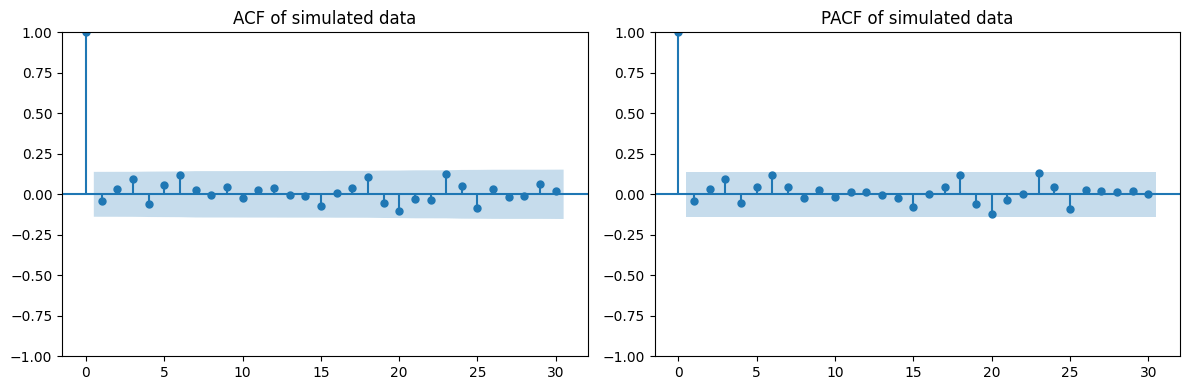

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -286.125
Date:                Sat, 25 Apr 2026   AIC                            580.250
Time:                        09:54:14   BIC                            593.443
Sample:                             0   HQIC                           585.589
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0907      0.100      0.906      0.365      -0.105       0.287
ar.L1          0.9406      0.148      6.346      0.000       0.650       1.231
ma.L1         -0.9170      0.176     -5.223      0.0

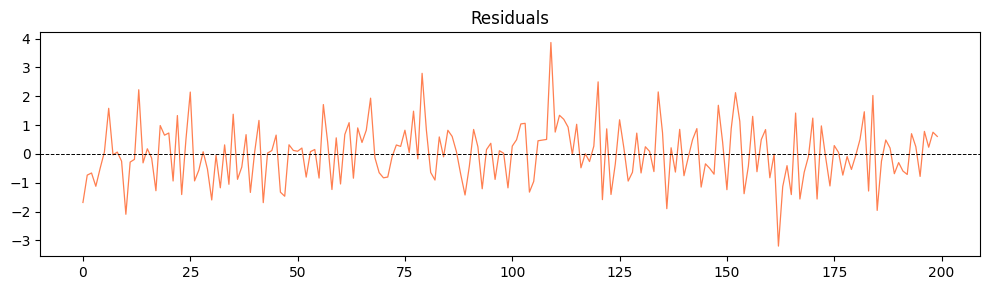

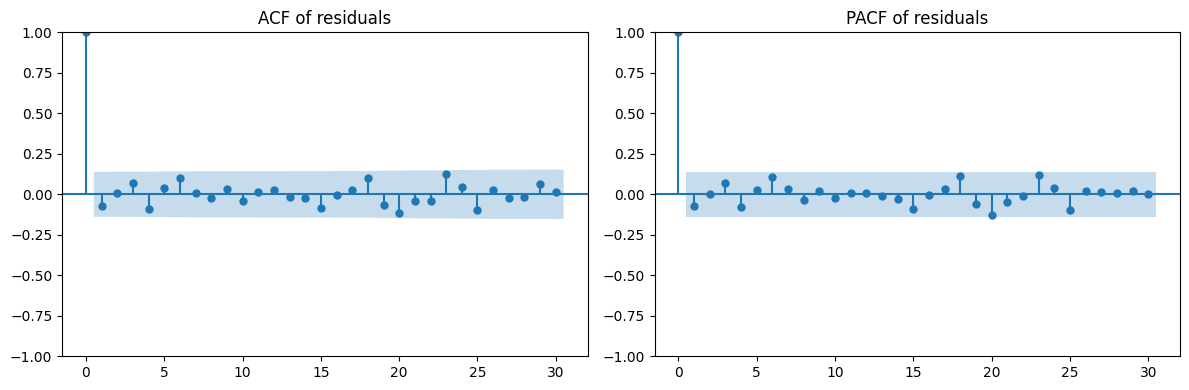

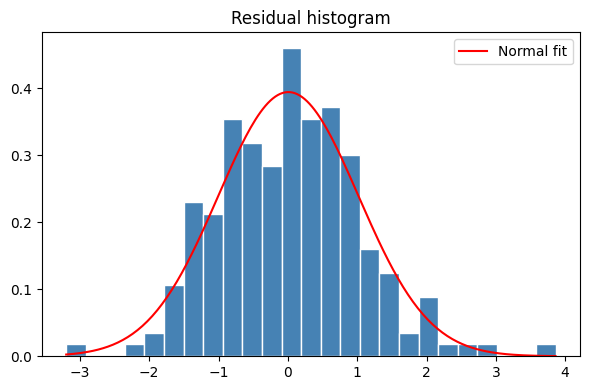


--- Ljung-Box Test ---
      lb_stat  lb_pvalue
10   6.772398   0.746743
20  15.048574   0.773622

--- Jarque-Bera Test ---
JB statistic : 7.4350
p-value      : 0.0243
Conclusion   : Reject normality at 5% level


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera, norm

np.random.seed(42)

# simulate ARMA(1,1): Xt = 0.97*Xt-1 + Zt - 0.9*Zt-1 (given)
T = 200
Z = np.random.normal(0, 1, T + 100)
X = np.zeros(T + 100)

for t in range(1, T + 100):
    X[t] = 0.97 * X[t-1] + Z[t] - 0.9 * Z[t-1]

X = X[100:]

plt.figure(figsize=(10, 3))
plt.plot(X, lw=0.9, color='steelblue')
plt.title('Simulated ARMA(1,1)  (T=200)')
plt.xlabel('t')
plt.ylabel('Xt')
plt.tight_layout()
plt.show()

# ACF and PACF of data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(X,  lags=30, ax=axes[0], title='ACF of simulated data')
plot_pacf(X, lags=30, ax=axes[1], title='PACF of simulated data', method='ywm')
plt.tight_layout()
plt.show()

# using MLE, fit ARMA(1,1)
result = ARIMA(X, order=(1, 0, 1)).fit()
print(result.summary())

print("\n--- True vs Estimated ---")
print(f"AR coeff   true:  0.9700   estimated: {result.arparams[0]:.4f}")
print(f"MA coeff   true: -0.9000   estimated: {result.maparams[0]:.4f}")
print(f"Intercept  true:  0.0000   estimated: {result.params[0]:.4f}")

resid = result.resid

# residual time plot
plt.figure(figsize=(10, 3))
plt.plot(resid, lw=0.9, color='coral')
plt.axhline(0, color='k', lw=0.7, ls='--')
plt.title('Residuals')
plt.tight_layout()
plt.show()

# ACF and PACF of residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid,  lags=30, ax=axes[0], title='ACF of residuals')
plot_pacf(resid, lags=30, ax=axes[1], title='PACF of residuals', method='ywm')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(resid, bins=25, edgecolor='white', color='steelblue', density=True)
xx = np.linspace(resid.min(), resid.max(), 200)
plt.plot(xx, norm.pdf(xx, resid.mean(), resid.std()), 'r-', lw=1.5, label='Normal fit')
plt.title('Residual histogram')
plt.legend()
plt.tight_layout()
plt.show()

# Ljung-Box white noise test
lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
print("\n--- Ljung-Box Test ---")
print(lb)

# Jarque-Bera normality test
jb_stat, jb_p = jarque_bera(resid)
print(f"\n--- Jarque-Bera Test ---")
print(f"JB statistic : {jb_stat:.4f}")
print(f"p-value      : {jb_p:.4f}")
print(f"Conclusion   : {'Fail to reject normality' if jb_p > 0.05 else 'Reject normality'} at 5% level")

# Simulation of the ARMA(1,1) process
We simulate T=200 observations from the model:
Xt = 0.97Xt−1 + Zt − 0.9Zt−1, Zt ∼ iid N(0,1)

To ensure the process starts from stationarity, we generate an additional 100 observations and discard them as burn-in.

The AR coefficient (0.97) is very close to 1, which makes the process highly persistent, shocks decay slowly over time. The MA coefficient (-0.9) introduces strong negative dependence at lag 1, partially offsetting this persistence.

# ACF and PACF of the simulated data
The ACF shows a slow, geometric decay toward zero, which is characteristic of an AR process with a coefficient close to 1. This indicates strong persistence in the data.

The PACF displays a dominant spike at lag 1 and then gradually declines. However, it does not cut off sharply due to the presence of the MA component.

Since neither the ACF nor PACF shows a clear cutoff, this behavior is consistent with a mixed ARMA process.

# Model fitting using MLE

We fit an ARMA(1,1) model using Maximum Likelihood Estimation (MLE), which estimates parameters by maximizing the likelihood of observing the data.

The estimated AR coefficient is approximately 0.94, which is very close to the true value of 0.97. Similarly, the estimated MA coefficient is about -0.92, closely matching the true value of -0.90. The estimated variance is around 1.02, again very close to the true value of 1.

The intercept is estimated to be approximately 0.09, but it is not statistically significant. This is consistent with the fact that the true mean of the process is zero.

Overall, the AR and MA coefficients are statistically significant and accurately recovered, and the small differences from the true values are expected given the finite sample size. The model provides a very good fit to the data.

# Residual analysis
The residuals fluctuate randomly around zero with no visible trend, clustering, or change in variance.

This indicates that the model has successfully captured the structure in the data, leaving only random noise.

# ACF and PACF of residuals
The ACF and PACF of the residuals show no significant spikes beyond lag 0. Most values lie within the 95% confidence bounds.

This suggests that the residuals behave like white noise, indicating that no autocorrelation remains in the data.

# Ljung-Box test for white noise
The Ljung-Box test evaluates whether residual autocorrelations are jointly zero.

- Lag 10: Q = 6.77, p-value = 0.747
- Lag 20: Q = 15.05, p-value = 0.774

Since both p-values are greater than 0.05, we fail to reject the null hypothesis. This confirms that the residuals are consistent with white noise.

# Jarque-Bera test for normality
The Jarque-Bera test checks whether the residuals follow a normal distribution.

- JB statistic = 7.44
- p-value = 0.024
- Skewness = 0.31
- Kurtosis = 3.71

The null hypothesis of normality is rejected at the 5% level. The residuals show slight right skewness and mildly heavy tails.

However, the deviation from normality is small, and with a sample size of 200, the test is sensitive to minor departures. In practice, this does not significantly affect the validity of the model.

# QUESTION 5

  Simulated T=200 observations from ARMA(1,1)
  True: φ₁=0.4, θ₁=0.35, σ²=2.25
  Sample mean : -0.1709  (expected ≈ 0)
  Sample var  : 3.4544  (theoretical = 3.7567)

  ESTIMATION RESULTS  (T = 200)
  True values:  φ₁ = 0.4,  θ₁ = 0.35,  σ² = 2.25
                 φ̂₁  Δφ  (est−0.40)     θ̂₁  Δθ  (est−0.35)     σ̂²  Δσ² (est−2.25)
Method                                                                              
YW (Moments)  0.3569         -0.0431  0.3314         -0.0186  2.2389         -0.0111
CLS           0.3457         -0.0543  0.3499         -0.0001  2.2805          0.0305
ML (Exact)    0.3129         -0.0871  0.3886          0.0386  2.2316         -0.0184
CML           0.3457         -0.0543  0.3499         -0.0001  2.2575          0.0075

  Absolute Errors  |φ̂−φ|, |θ̂−θ|, |σ̂²−σ²|:
  YW (Moments)         |Δφ|=0.0431  |Δθ|=0.0186  |Δσ²|=0.0111
  CLS                  |Δφ|=0.0543  |Δθ|=0.0001  |Δσ²|=0.0305
  ML (Exact)           |Δφ|=0.0871  |Δθ|=0.0386  |Δσ²|=0.0184
  CML     

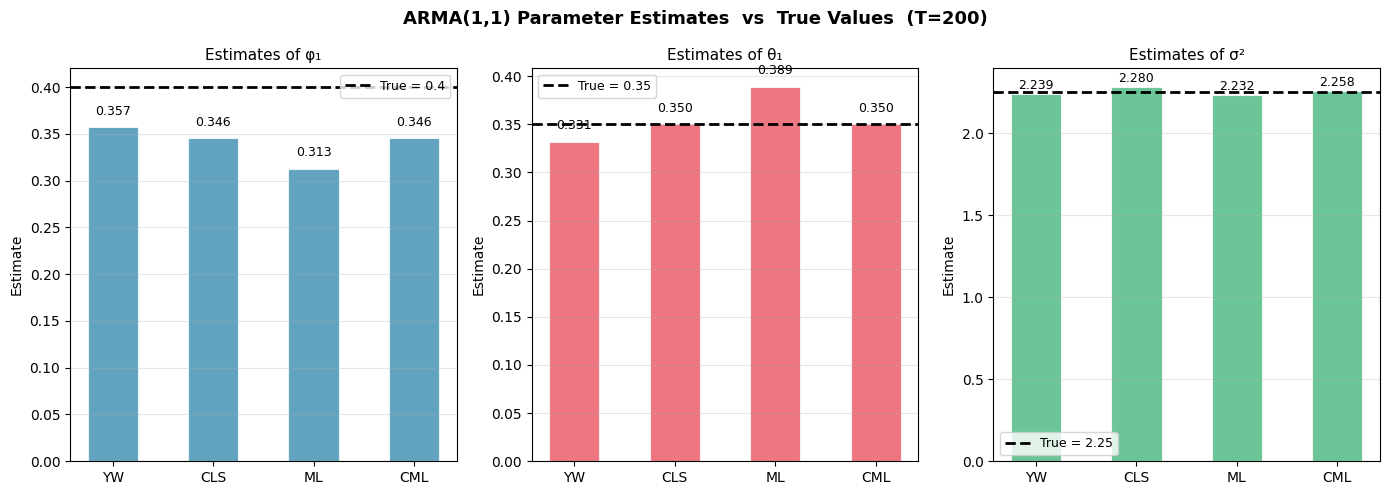

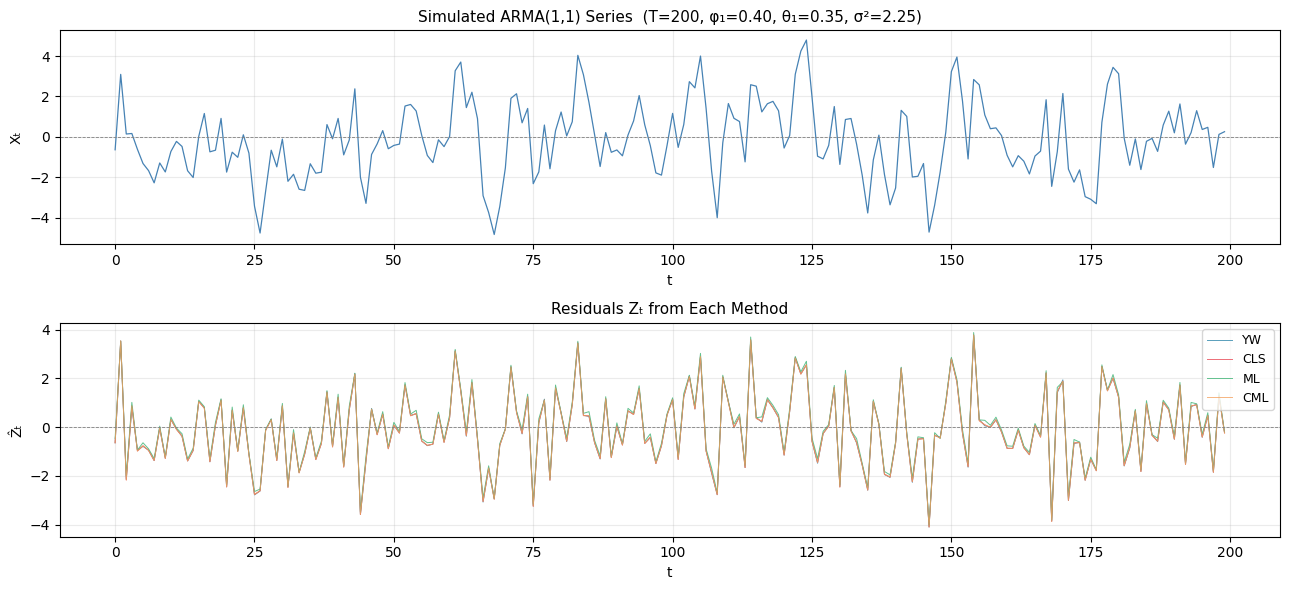

In [ ]:
# ================================================================
#  ARMA(1,1) Estimation — YW, CLS, ML, CML  (Google Colab)
#  True params: φ₁ = 0.40,  θ₁ = 0.35,  σ² = 2.25,  T = 200
# ================================================================

!pip install statsmodels --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model  import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools    import acf as sm_acf
from scipy.optimize               import minimize

# ── Reproducibility ───────────────────────────────────────────
np.random.seed(42)

# ── True parameters ───────────────────────────────────────────
PHI_TRUE   = 0.40
THETA_TRUE = 0.35
SIG2_TRUE  = 2.25
SIG_TRUE   = np.sqrt(SIG2_TRUE)
T          = 200

# ================================================================
#  STEP 1 — Simulate ARMA(1,1)
#  Model: Xₜ = φXₜ₋₁ + Zₜ + θZₜ₋₁
# ================================================================
ar_poly = np.array([1, -PHI_TRUE])    # statsmodels: [1, -φ₁]
ma_poly = np.array([1,  THETA_TRUE])  # statsmodels: [1,  θ₁]

X = ArmaProcess(ar_poly, ma_poly).generate_sample(
        nsample=T, scale=SIG_TRUE, burnin=500)

print("="*60)
print(f"  Simulated T={T} observations from ARMA(1,1)")
print(f"  True: φ₁={PHI_TRUE}, θ₁={THETA_TRUE}, σ²={SIG2_TRUE}")
print("="*60)
print(f"  Sample mean : {X.mean():.4f}  (expected ≈ 0)")
print(f"  Sample var  : {X.var():.4f}  "
      f"(theoretical = {SIG2_TRUE*(1+2*PHI_TRUE*THETA_TRUE+THETA_TRUE**2)/(1-PHI_TRUE**2):.4f})")


# ================================================================
#  STEP 2 — METHOD 1: Yule-Walker (Method of Moments)
# ================================================================
# For ARMA(1,1):
#   ρ(k) = φ·ρ(k-1)   for k ≥ 2   →  φ̂ = r(2)/r(1)
#   ρ(1) = (φ+θ)(1+φθ)/(1+2φθ+θ²) → solve quadratic for θ̂
#   γ(0) = σ²(1+2φθ+θ²)/(1−φ²)    → σ̂²

def yule_walker_arma11(X):
    r   = sm_acf(X, nlags=2, fft=True)   # r[0]=1, r[1]=ρ(1), r[2]=ρ(2)
    g0  = np.var(X, ddof=0)              # sample variance γ̂(0)
    r1, r2 = r[1], r[2]

    # φ̂ from ρ(2)/ρ(1)
    phi_hat = r2 / r1 if abs(r1) > 1e-10 else 0.0

    # Solve quadratic: (ρ(1)−φ)θ² + (2ρ(1)φ − φ² − 1)θ + (ρ(1)−φ) = 0
    a = r1 - phi_hat
    b = 2*r1*phi_hat - phi_hat**2 - 1
    c = r1 - phi_hat

    discriminant = b**2 - 4*a*c
    if abs(a) < 1e-10:          # degenerate case
        theta_hat = 0.0
    elif discriminant < 0:
        theta_hat = -b / (2*a)  # real part only
    else:
        t1 = (-b + np.sqrt(discriminant)) / (2*a)
        t2 = (-b - np.sqrt(discriminant)) / (2*a)
        # Invertibility: pick |θ| < 1; prefer closer to 0
        candidates = [t for t in [t1, t2] if abs(t) < 1]
        theta_hat  = min(candidates, key=abs) if candidates else t1

    # σ̂² from γ(0)
    denom    = 1 + 2*phi_hat*theta_hat + theta_hat**2
    sig2_hat = g0 * (1 - phi_hat**2) / denom if denom > 0 else g0

    return phi_hat, theta_hat, sig2_hat

phi_yw, theta_yw, sig2_yw = yule_walker_arma11(X)


# ================================================================
#  STEP 3 — METHOD 2: Conditional Least Squares (CLS)
# ================================================================
# Minimise S(φ,θ) = Σₜ Ẑₜ²  where Ẑₜ are back-computed residuals
# conditioning on Ẑ₁ = 0.

def cls_residuals(params, X):
    """Back-compute residuals given (phi, theta)."""
    phi, theta = params
    n   = len(X)
    Z   = np.zeros(n)
    Z[0] = X[0]                  # condition Z₁ = 0  (≈ E[Z₁])
    for t in range(1, n):
        Z[t] = X[t] - phi*X[t-1] - theta*Z[t-1]
    return Z

def cls_loss(params, X):
    Z = cls_residuals(params, X)
    return np.sum(Z[1:]**2)      # drop conditioned first residual

result_cls = minimize(
    cls_loss,
    x0     = [0.3, 0.3],         # reasonable starting values
    args   = (X,),
    method = 'L-BFGS-B',
    bounds = [(-0.99, 0.99), (-0.99, 0.99)]
)
phi_cls, theta_cls = result_cls.x
Z_cls   = cls_residuals([phi_cls, theta_cls], X)
sig2_cls = np.sum(Z_cls[1:]**2) / (T - 1 - 2)   # df = T-1-k, k=2 params


# ================================================================
#  STEP 4 — METHOD 3: Full Maximum Likelihood (ML)
# ================================================================
# Uses exact Gaussian likelihood via Kalman filter (state-space).

mod_ml   = ARIMA(X, order=(1, 0, 1)).fit(method='statespace', cov_type='none')
phi_ml   = float(mod_ml.arparams[0])
theta_ml = float(mod_ml.maparams[0])
sig2_ml  = float(mod_ml.params[-1])    # last param = σ² (variance)


# ================================================================
#  STEP 5 — METHOD 4: Conditional Maximum Likelihood (CML)
# ================================================================
# Maximises the conditional Gaussian log-likelihood
# (conditions on pre-sample values = 0).
# Equivalent to minimising -log L_cond.

def cml_neg_loglik(params, X):
    """Conditional Gaussian log-likelihood for ARMA(1,1)."""
    phi, theta, log_sig2 = params
    sig2 = np.exp(log_sig2)          # ensure positivity
    if abs(phi) >= 1 or abs(theta) >= 1:
        return 1e10
    Z   = cls_residuals([phi, theta], X)
    n   = len(Z) - 1                 # discard conditioned obs
    llik = -0.5 * n * np.log(2*np.pi*sig2) - np.sum(Z[1:]**2) / (2*sig2)
    return -llik

result_cml = minimize(
    cml_neg_loglik,
    x0     = [phi_cls, theta_cls, np.log(sig2_cls)],
    args   = (X,),
    method = 'L-BFGS-B',
    bounds = [(-0.99, 0.99), (-0.99, 0.99), (-5, 5)]
)
phi_cml, theta_cml, log_sig2_cml = result_cml.x
sig2_cml = np.exp(log_sig2_cml)


# ================================================================
#  STEP 6 — Results Table
# ================================================================
methods  = ['YW (Moments)', 'CLS', 'ML (Exact)', 'CML']
phis     = [phi_yw,   phi_cls,   phi_ml,   phi_cml  ]
thetas   = [theta_yw, theta_cls, theta_ml, theta_cml]
sig2s    = [sig2_yw,  sig2_cls,  sig2_ml,  sig2_cml ]

rows = []
for m, ph, th, s2 in zip(methods, phis, thetas, sig2s):
    rows.append({
        'Method'           : m,
        'φ̂₁'             : round(ph, 4),
        'Δφ  (est−0.40)'  : round(ph - PHI_TRUE,   4),
        'θ̂₁'             : round(th, 4),
        'Δθ  (est−0.35)'  : round(th - THETA_TRUE, 4),
        'σ̂²'             : round(s2, 4),
        'Δσ² (est−2.25)'  : round(s2 - SIG2_TRUE,  4),
    })

df = pd.DataFrame(rows).set_index('Method')

print("\n" + "="*72)
print(f"  ESTIMATION RESULTS  (T = {T})")
print(f"  True values:  φ₁ = {PHI_TRUE},  θ₁ = {THETA_TRUE},  σ² = {SIG2_TRUE}")
print("="*72)
print(df.to_string())
print("="*72)

# ── Absolute error summary ──
print("\n  Absolute Errors  |φ̂−φ|, |θ̂−θ|, |σ̂²−σ²|:")
for m, ph, th, s2 in zip(methods, phis, thetas, sig2s):
    print(f"  {m:<20} |Δφ|={abs(ph-PHI_TRUE):.4f}  "
          f"|Δθ|={abs(th-THETA_TRUE):.4f}  "
          f"|Δσ²|={abs(s2-SIG2_TRUE):.4f}")


# ================================================================
#  STEP 7 — Visual Comparison (Bar Chart)
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(f'ARMA(1,1) Parameter Estimates  vs  True Values  (T={T})',
             fontsize=13, fontweight='bold')

params_info = [
    ('φ₁',  phis,   PHI_TRUE,   '#2E86AB'),
    ('θ₁',  thetas, THETA_TRUE, '#E84855'),
    ('σ²',  sig2s,  SIG2_TRUE,  '#3BB273'),
]
x = np.arange(len(methods))
bar_w = 0.5

for ax, (name, vals, true_val, col) in zip(axes, params_info):
    bars = ax.bar(x, vals, width=bar_w, color=col, alpha=0.75,
                  edgecolor='white', linewidth=0.8)
    ax.axhline(true_val, color='black', linestyle='--',
               linewidth=2, label=f'True = {true_val}')
    ax.set_title(f'Estimates of {name}', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(['YW', 'CLS', 'ML', 'CML'], fontsize=10)
    ax.set_ylabel('Estimate')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # annotate bar values
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


# ================================================================
#  STEP 8 — Time Series + ACF of Residuals
# ================================================================
# Collect residuals from each method
Z_yw  = cls_residuals([phi_yw,  theta_yw],  X)
Z_ml  = mod_ml.resid
Z_cml = cls_residuals([phi_cml, theta_cml], X)

resid_dict = {'YW': Z_yw, 'CLS': Z_cls, 'ML': Z_ml, 'CML': Z_cml}

fig, axes = plt.subplots(2, 1, figsize=(13, 6))

axes[0].plot(X, color='steelblue', linewidth=0.9)
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.6)
axes[0].set_title(f'Simulated ARMA(1,1) Series  (T={T}, φ₁=0.40, θ₁=0.35, σ²=2.25)',
                  fontsize=11)
axes[0].set_xlabel('t'); axes[0].set_ylabel('Xₜ'); axes[0].grid(alpha=0.25)

colors_r = ['#2E86AB', '#E84855', '#3BB273', '#F4A261']
for (m, Z), col in zip(resid_dict.items(), colors_r):
    axes[1].plot(Z, linewidth=0.7, alpha=0.8, label=m, color=col)
axes[1].axhline(0, color='grey', linestyle='--', linewidth=0.6)
axes[1].set_title('Residuals Zₜ from Each Method', fontsize=11)
axes[1].set_xlabel('t'); axes[1].set_ylabel('Ẑₜ')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Comments on the findings

* The simulated series behaves as expected for a stationary ARMA(1,1) process: the sample mean is close to zero, and the sample variance is reasonably close to the theoretical value. Small deviations are normal for a finite sample of length (T=200).

* Overall, all four estimation methods recover the true parameters fairly well. None of the estimates is wildly off, which suggests the simulation and fitting procedure are working correctly.

* The **YW (method of moments)** estimates are quite close to the true values for all three parameters. In particular, (\hat{\phi}_1) and (\hat{\theta}_1) are slightly underestimated, while (\hat{\sigma}^2) is almost exact.

* The **CLS** and **CML** estimates are identical for (\hat{\phi}_1) and (\hat{\theta}_1), which is consistent with the fact that both approaches are based on conditional fitting. Their variance estimates are also very close to the true value, with CML giving the smallest error for (\sigma^2).

* The **exact ML** fit shows the largest deviation in (\hat{\phi}_1) and a noticeable overestimation of (\hat{\theta}_1). This is not unusual in small samples, because maximum likelihood can be more sensitive to the particular realization of the data.

* In terms of absolute error, **YW performs best for (\phi_1)**, **CLS/CML perform best for (\theta_1)**, and **CML performs best for (\sigma^2)**.

* The residual plots from all methods are almost overlapping, which suggests that the fitted models are producing very similar innovation sequences and that no method is dramatically outperforming the others for this single realization.

* A key takeaway is that with (T=200), estimation error is still visible. The differences across methods are mostly due to finite-sample variation rather than any major model failure.

* If one had to summarize the results in one line: **all four methods are acceptable here, but YW is slightly closer for (\phi_1), while CML gives the most balanced overall fit.**


════════════════════════════════════════════════════════════════════
  T = 250  |  True: φ₁=0.4, θ₁=0.35, σ²=2.25
════════════════════════════════════════════════════════════════════
           φ̂₁  Δφ (est−0.40)     θ̂₁  Δθ (est−0.35)     σ̂²  Δσ²(est−2.25)
Method                                                                     
YW      0.3473        -0.0527  0.3316        -0.0184  2.1961        -0.0539
CLS     0.3859        -0.0141  0.2951        -0.0549  2.2357        -0.0143
ML      0.3614        -0.0386  0.3178        -0.0322  2.1916        -0.0584
CML     0.3859        -0.0141  0.2951        -0.0549  2.2178        -0.0322

════════════════════════════════════════════════════════════════════
  T = 500  |  True: φ₁=0.4, θ₁=0.35, σ²=2.25
════════════════════════════════════════════════════════════════════
           φ̂₁  Δφ (est−0.40)     θ̂₁  Δθ (est−0.35)     σ̂²  Δσ²(est−2.25)
Method                                                                     
YW      0.3641        -0

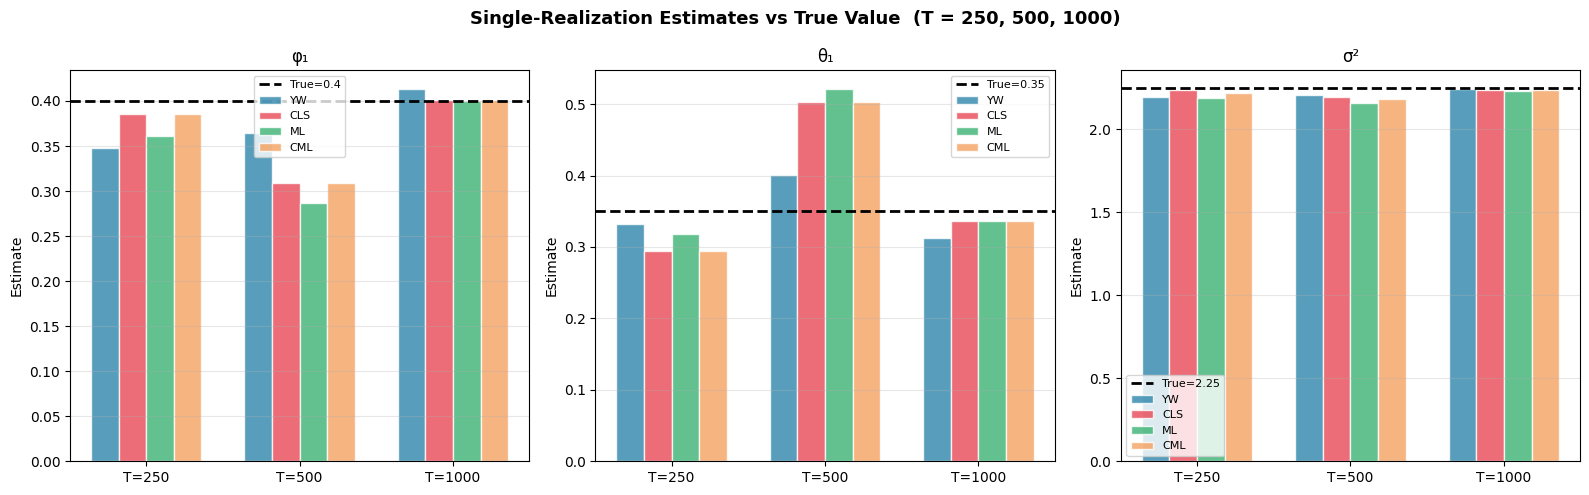

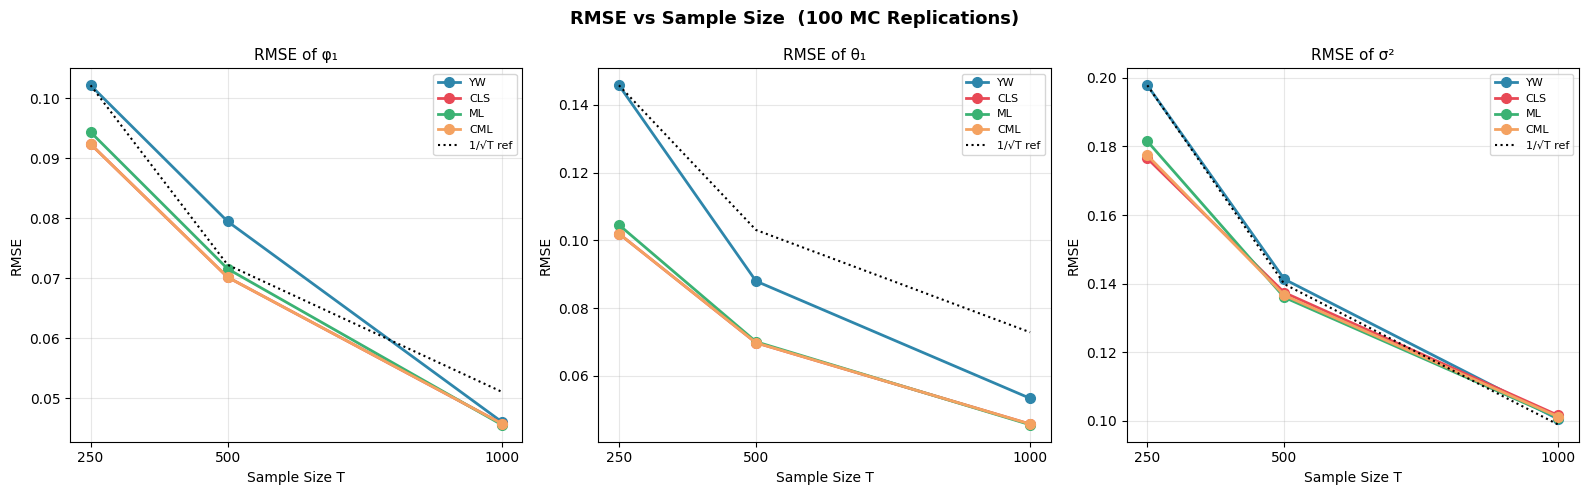

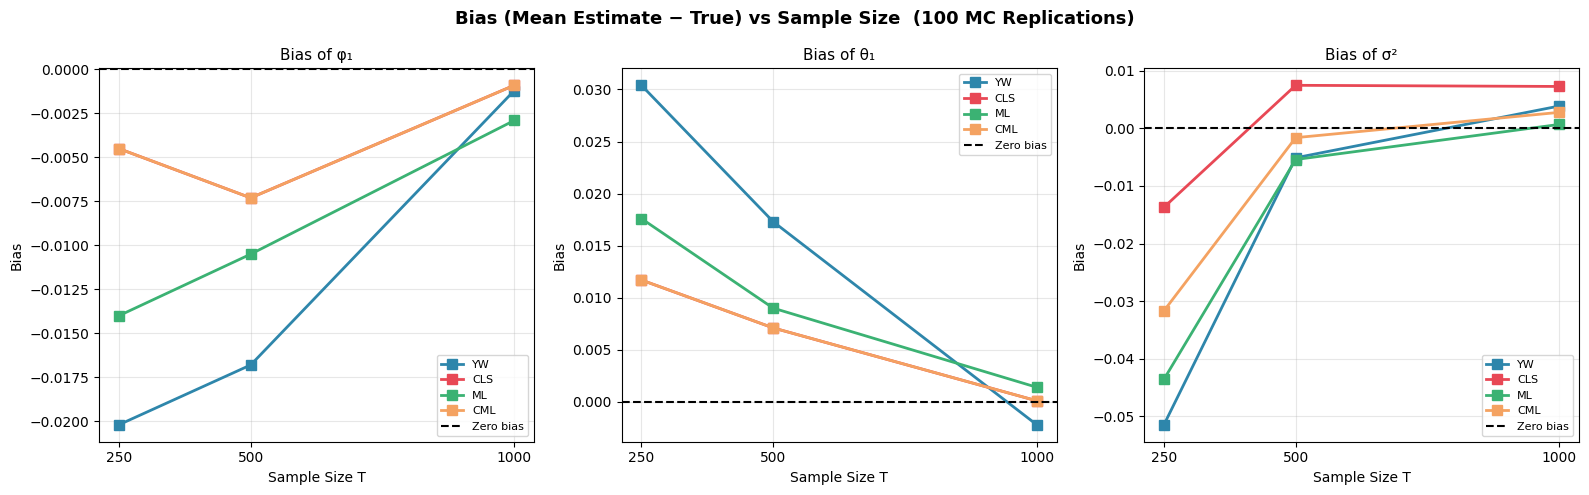

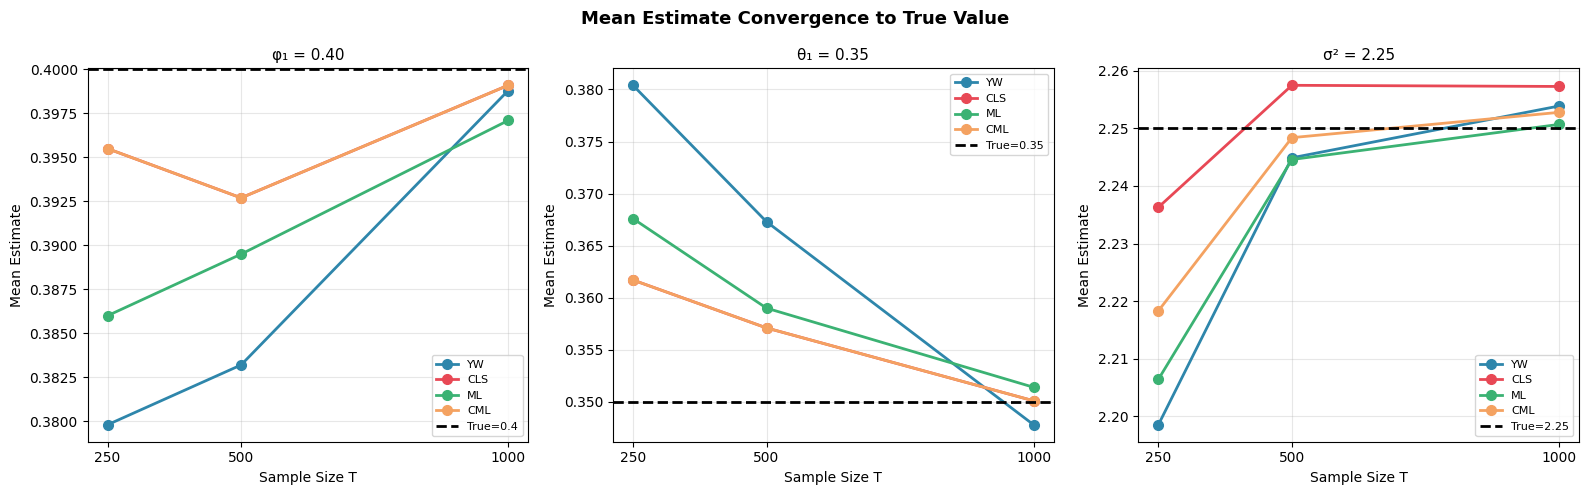

In [ ]:
np.random.seed(42)

# ── True parameters ───────────────────────────────────────────
PHI   = 0.40
THETA = 0.35
SIG2  = 2.25
SIG   = np.sqrt(SIG2)
SIZES = [250, 500, 1000]

# ================================================================
#  CORE ESTIMATION FUNCTIONS  (identical logic to T=200 script)
# ================================================================

# ── YW ─────────────────────────────────────────────────────────
def yule_walker_arma11(X):
    r   = sm_acf(X, nlags=2, fft=True)
    g0  = np.var(X, ddof=0)
    r1, r2 = r[1], r[2]

    phi_hat = r2 / r1 if abs(r1) > 1e-10 else 0.0

    a = r1 - phi_hat
    b = 2*r1*phi_hat - phi_hat**2 - 1
    c = r1 - phi_hat
    disc = b**2 - 4*a*c

    if abs(a) < 1e-10:
        theta_hat = 0.0
    elif disc < 0:
        theta_hat = -b / (2*a)
    else:
        t1 = (-b + np.sqrt(disc)) / (2*a)
        t2 = (-b - np.sqrt(disc)) / (2*a)
        cands = [t for t in [t1, t2] if abs(t) < 1]
        theta_hat = min(cands, key=abs) if cands else t1

    denom    = 1 + 2*phi_hat*theta_hat + theta_hat**2
    sig2_hat = g0 * (1 - phi_hat**2) / denom if denom > 0 else g0
    return phi_hat, theta_hat, sig2_hat


# ── Back-compute residuals (shared by CLS & CML) ───────────────
def backcompute_residuals(params, X):
    phi, theta = params
    n   = len(X)
    Z   = np.zeros(n)
    Z[0] = X[0]
    for t in range(1, n):
        Z[t] = X[t] - phi*X[t-1] - theta*Z[t-1]
    return Z


# ── CLS ────────────────────────────────────────────────────────
def fit_cls(X):
    def loss(p): return np.sum(backcompute_residuals(p, X)[1:]**2)
    res  = minimize(loss, x0=[0.3, 0.3], method='L-BFGS-B',
                    bounds=[(-0.99,0.99),(-0.99,0.99)])
    phi_cls, theta_cls = res.x
    Z    = backcompute_residuals([phi_cls, theta_cls], X)
    s2   = np.sum(Z[1:]**2) / (len(X) - 3)
    return phi_cls, theta_cls, s2


# ── ML  ────────────────────────────────────────────────────────
def fit_ml(X):
    mod  = ARIMA(X, order=(1,0,1)).fit(method='statespace', cov_type='none')
    return float(mod.arparams[0]), float(mod.maparams[0]), float(mod.params[-1])


# ── CML ────────────────────────────────────────────────────────
def fit_cml(X):
    def neg_loglik(p):
        phi, theta, log_s2 = p
        s2 = np.exp(log_s2)
        if abs(phi) >= 1 or abs(theta) >= 1: return 1e10
        Z  = backcompute_residuals([phi, theta], X)
        n  = len(Z) - 1
        return 0.5*n*np.log(2*np.pi*s2) + np.sum(Z[1:]**2)/(2*s2)

    phi0, th0, s20 = fit_cls(X)
    res = minimize(neg_loglik, x0=[phi0, th0, np.log(s20)],
                   method='L-BFGS-B',
                   bounds=[(-0.99,0.99),(-0.99,0.99),(-6,6)])
    p, t, ls = res.x
    return p, t, np.exp(ls)


# ── Run all four for one series ────────────────────────────────
def fit_all(X):
    return {
        'YW' : yule_walker_arma11(X),
        'CLS': fit_cls(X),
        'ML' : fit_ml(X),
        'CML': fit_cml(X),
    }


# ================================================================
#  SINGLE-REALIZATION ESTIMATION FOR EACH T
# ================================================================
results_single = {}   # T -> {method -> (phi, theta, sig2)}

for T in SIZES:
    ar = np.array([1, -PHI]);  ma = np.array([1, THETA])
    X  = ArmaProcess(ar, ma).generate_sample(nsample=T, scale=SIG, burnin=500)
    results_single[T] = fit_all(X)

# ── Print tables ──────────────────────────────────────────────
METHODS = ['YW', 'CLS', 'ML', 'CML']

def print_table(res, T):
    rows = []
    for m in METHODS:
        ph, th, s2 = res[m]
        rows.append({'Method': m,
                     'φ̂₁':           round(ph, 4),
                     'Δφ (est−0.40)': round(ph-PHI,   4),
                     'θ̂₁':           round(th, 4),
                     'Δθ (est−0.35)': round(th-THETA, 4),
                     'σ̂²':           round(s2, 4),
                     'Δσ²(est−2.25)': round(s2-SIG2,  4)})
    df = pd.DataFrame(rows).set_index('Method')
    print(f"\n{'═'*68}")
    print(f"  T = {T}  |  True: φ₁={PHI}, θ₁={THETA}, σ²={SIG2}")
    print(f"{'═'*68}")
    print(df.to_string())

for T in SIZES:
    print_table(results_single[T], T)


# ================================================================
#  MONTE CARLO  (100 replications per T)  — Bias + RMSE
# ================================================================
N_SIM = 100
print(f"\n\n{'═'*68}")
print(f"  MONTE CARLO  ({N_SIM} replications per T)")
print(f"{'═'*68}")

mc_results = {}   # T -> DataFrame

for T in SIZES:
    collector = {m: [] for m in METHODS}

    for rep in range(N_SIM):
        ar = np.array([1, -PHI]);  ma = np.array([1, THETA])
        X  = ArmaProcess(ar, ma).generate_sample(nsample=T, scale=SIG, burnin=500)
        est = fit_all(X)
        for m in METHODS:
            collector[m].append(est[m])

    rows = []
    for m in METHODS:
        arr  = np.array(collector[m])         # (N_SIM, 3)
        mp, mt, ms = np.nanmean(arr, axis=0)
        rp   = np.sqrt(np.nanmean((arr[:,0]-PHI  )**2))
        rt   = np.sqrt(np.nanmean((arr[:,1]-THETA)**2))
        rs   = np.sqrt(np.nanmean((arr[:,2]-SIG2 )**2))
        bp   = mp - PHI;   bt = mt - THETA;   bs = ms - SIG2
        rows.append({'Method': m,
                     'Mean φ̂₁': round(mp,4), 'Bias φ': round(bp,4), 'RMSE φ': round(rp,4),
                     'Mean θ̂₁': round(mt,4), 'Bias θ': round(bt,4), 'RMSE θ': round(rt,4),
                     'Mean σ̂²': round(ms,4), 'Bias σ²': round(bs,4),'RMSE σ²': round(rs,4)})

    df_mc = pd.DataFrame(rows).set_index('Method')
    mc_results[T] = df_mc

    print(f"\n── T = {T}  (MC averages, {N_SIM} runs) ──")
    print(df_mc.to_string())


# ================================================================
#  RMSE CONVERGENCE TABLE  (across T)
# ================================================================
print(f"\n\n{'═'*68}")
print("  RMSE CONVERGENCE TABLE")
print(f"{'═'*68}")

for param_col, true_val, label in [
        ('RMSE φ', PHI,   'φ₁'),
        ('RMSE θ', THETA, 'θ₁'),
        ('RMSE σ²',SIG2,  'σ²')]:
    tbl = pd.DataFrame({T: mc_results[T][param_col] for T in SIZES})
    print(f"\n  RMSE of {label} (true={true_val})")
    print(tbl.to_string())
    # Convergence ratios
    ratios = []
    for m in METHODS:
        r1 = mc_results[250][param_col][m]
        r2 = mc_results[500][param_col][m]
        r3 = mc_results[1000][param_col][m]
        ratios.append({'Method': m,
                       '500/250': round(r2/r1,3) if r1>0 else np.nan,
                       '1000/500': round(r3/r2,3) if r2>0 else np.nan,
                       '(ideal ≈ 0.707)': '1/√2'})
    print(pd.DataFrame(ratios).set_index('Method').to_string())


# ================================================================
#  VISUALISATION 1 — Single-Realization Estimates vs True
# ================================================================
param_names   = ['φ₁', 'θ₁', 'σ²']
true_vals     = [PHI, THETA, SIG2]
param_indices = [0, 1, 2]
colors_m      = {'YW':'#2E86AB','CLS':'#E84855','ML':'#3BB273','CML':'#F4A261'}
x_pos         = np.arange(len(SIZES))
bar_w         = 0.18
offsets       = [-1.5, -0.5, 0.5, 1.5]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Single-Realization Estimates vs True Value  (T = 250, 500, 1000)',
             fontsize=13, fontweight='bold')

for ax, pname, true_val, pidx in zip(axes, param_names, true_vals, param_indices):
    for m, off in zip(METHODS, offsets):
        vals = [results_single[T][m][pidx] for T in SIZES]
        ax.bar(x_pos + off*bar_w, vals, width=bar_w, label=m,
               color=colors_m[m], alpha=0.80, edgecolor='white')
    ax.axhline(true_val, color='black', linestyle='--', linewidth=2,
               label=f'True={true_val}')
    ax.set_title(f'{pname}', fontsize=12)
    ax.set_xticks(x_pos); ax.set_xticklabels([f'T={T}' for T in SIZES])
    ax.set_ylabel('Estimate'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


# ================================================================
#  VISUALISATION 2 — RMSE Decay (MC) across T
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'RMSE vs Sample Size  ({N_SIM} MC Replications)',
             fontsize=13, fontweight='bold')

for ax, (col, lbl, tv) in zip(axes, [
        ('RMSE φ','RMSE of φ₁',PHI),
        ('RMSE θ','RMSE of θ₁',THETA),
        ('RMSE σ²','RMSE of σ²',SIG2)]):

    for m, col_m in colors_m.items():
        vals = [mc_results[T].loc[m, col] for T in SIZES]
        ax.plot(SIZES, vals, marker='o', linewidth=2, markersize=7,
                label=m, color=col_m)

    # theoretical 1/√T reference curve scaled to YW at T=250
    ref0 = mc_results[250].loc['YW', col]
    theory = [ref0 * np.sqrt(250/T) for T in SIZES]
    ax.plot(SIZES, theory, 'k:', linewidth=1.5, label='1/√T ref')

    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel('Sample Size T'); ax.set_ylabel('RMSE')
    ax.set_xticks(SIZES); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


# ================================================================
#  VISUALISATION 3 — Bias across T
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Bias (Mean Estimate − True) vs Sample Size  ({N_SIM} MC Replications)',
             fontsize=13, fontweight='bold')

for ax, (col, lbl) in zip(axes, [
        ('Bias φ','Bias of φ₁'),
        ('Bias θ','Bias of θ₁'),
        ('Bias σ²','Bias of σ²')]):
    for m, col_m in colors_m.items():
        vals = [mc_results[T].loc[m, col] for T in SIZES]
        ax.plot(SIZES, vals, marker='s', linewidth=2, markersize=7,
                label=m, color=col_m)
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero bias')
    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel('Sample Size T'); ax.set_ylabel('Bias')
    ax.set_xticks(SIZES); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


# ================================================================
#  VISUALISATION 4 — Mean Estimate Convergence to True Value
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mean Estimate Convergence to True Value',
             fontsize=13, fontweight='bold')

for ax, (mean_col, lbl, tv) in zip(axes, [
        ('Mean φ̂₁','φ₁ = 0.40', PHI),
        ('Mean θ̂₁','θ₁ = 0.35', THETA),
        ('Mean σ̂²','σ² = 2.25', SIG2)]):
    for m, col_m in colors_m.items():
        vals = [mc_results[T].loc[m, mean_col] for T in SIZES]
        ax.plot(SIZES, vals, marker='o', linewidth=2, markersize=7,
                label=m, color=col_m)
    ax.axhline(tv, color='black', linestyle='--', linewidth=2, label=f'True={tv}')
    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel('Sample Size T'); ax.set_ylabel('Mean Estimate')
    ax.set_xticks(SIZES); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Comments on the findings (Part b: Increasing sample size)

* As the sample size increases from (T=250 \rightarrow 500 \rightarrow 1000), the estimates from all methods move closer to the true parameter values. This is clear evidence of **consistency** of all four estimators (YW, CLS, ML, CML).

* The **single-realization results** show noticeable variability at smaller sample sizes, especially at (T=250) and (T=500). For example, at (T=500), some methods (especially ML/CLS) produce quite poor estimates of (\theta_1), highlighting that **one realization can be misleading** even with moderate sample sizes.

* However, the **Monte Carlo averages (100 replications)** reveal the true behavior: the mean estimates steadily converge to the true parameters as (T) increases, and biases shrink toward zero for all methods.

* The **bias plots** confirm that:

  * Bias in (\phi_1) is initially negative (underestimation) but vanishes as (T \to 1000).
  * Bias in (\theta_1) is small and decreases quickly with sample size.
  * Bias in (\sigma^2) also diminishes and becomes negligible for large (T).

* The **RMSE decreases consistently** with increasing sample size for all parameters and methods. This indicates improved estimation accuracy and reduced variability.

* Importantly, the rate of RMSE decay approximately follows the theoretical rate ( \sim 1/\sqrt{T} ), as seen from the RMSE ratios being close to (0.707). This validates the expected **asymptotic efficiency behavior**.

* In terms of comparison across methods:

  * **CLS and CML consistently perform slightly better** (lower RMSE) than YW, especially for (\theta_1).
  * **ML and CML are nearly identical in performance**, particularly for larger (T), as expected theoretically.
  * **YW performs slightly worse**, especially at smaller sample sizes, but the gap closes as (T) increases.

* By (T=1000), **all methods become nearly indistinguishable**, with very small bias and almost identical RMSE values. This suggests that for large samples, the choice of estimation method is less critical.

* A key takeaway is:

  > Increasing sample size significantly improves estimation quality, reduces bias and variance, and ensures all methods converge to the true parameters, with ML/CML/CLS having a slight edge over Yule-Walker in finite samples.

* Finally, this exercise highlights an important practical insight:

  > **Monte Carlo analysis is essential** to properly evaluate estimator performance, since single realizations can give misleading impressions, especially at moderate sample sizes.

# QUESTION 6

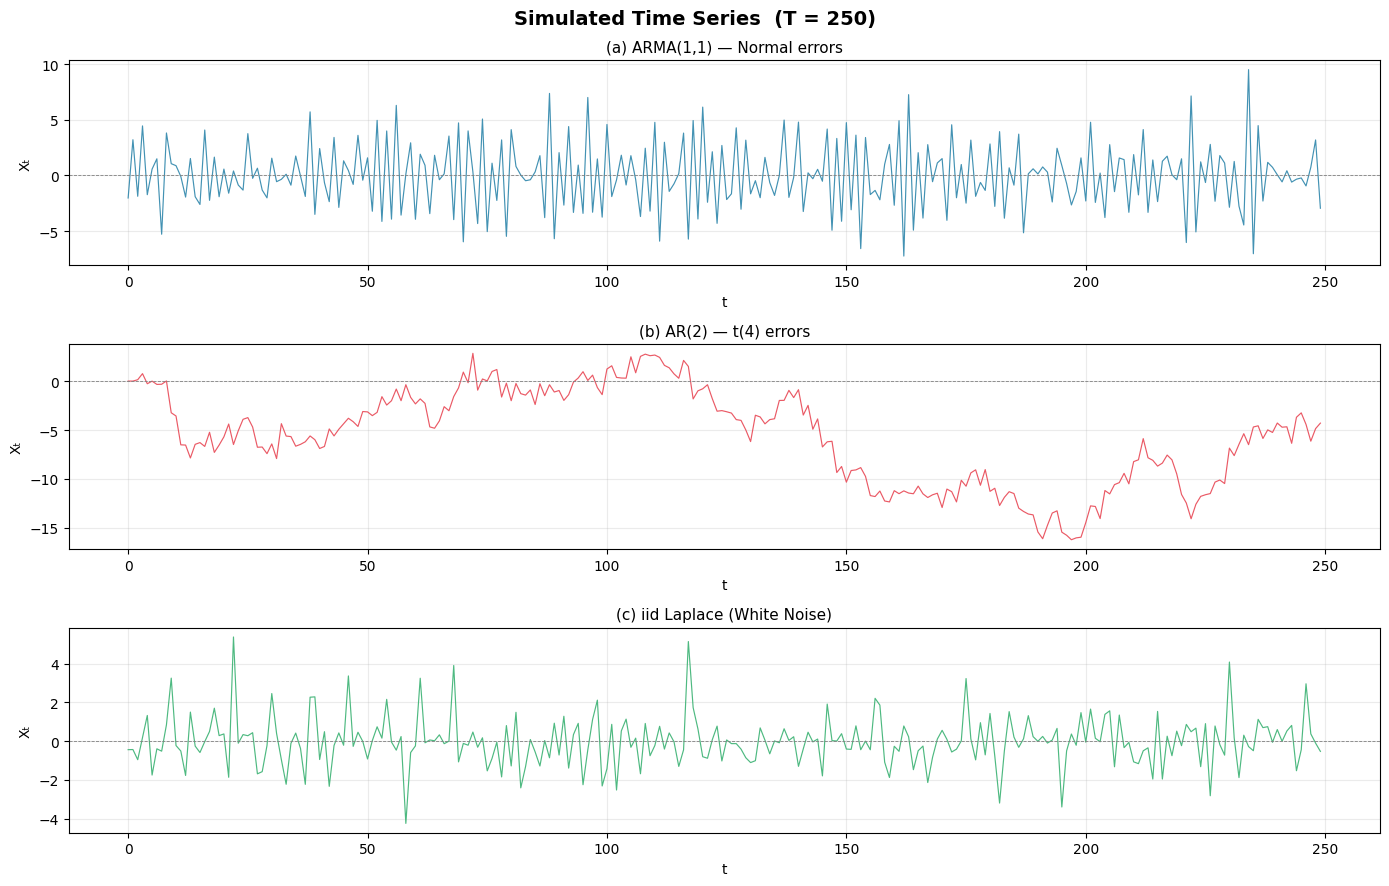

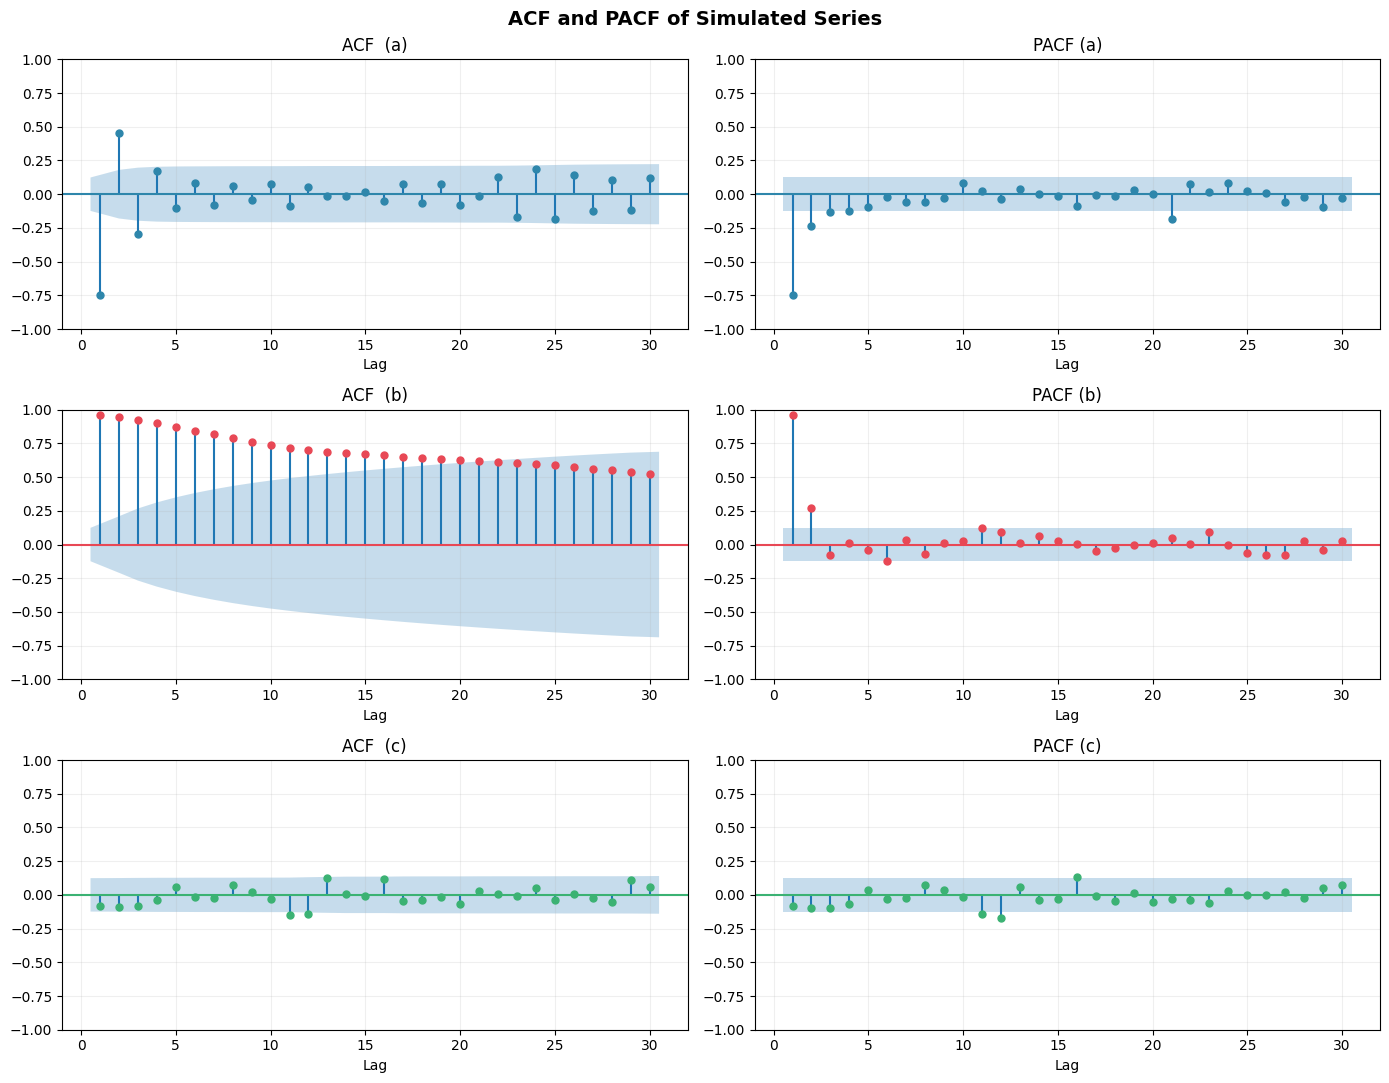


════════════════════════════════════════════════════════════════════
  SECTION 3 — UNIT ROOT TESTS
════════════════════════════════════════════════════════════════════

  ADF  H₀: Series has a unit root  (non-stationary)
           Reject H₀ → stationary
  KPSS H₀: Series is stationary
           Reject H₀ → non-stationary
  Conclusion drawn when both tests agree.

  ── (a) ARMA(1,1) — Normal errors ──
  ADF  (const)        stat=-11.5648  p=0.0000  lags=3  REJECT H₀ → stationary
  ADF  (const+trend)  stat=-10.3272  p=0.0000  lags=4  REJECT H₀ → stationary
  ADF  (none)         stat=-11.5867  p=0.0000  lags=3  REJECT H₀ → stationary
  KPSS (level)        stat=  0.2678  p=0.1000       FAIL TO REJECT → stationary
  KPSS (trend)        stat=  0.0522  p=0.1000       FAIL TO REJECT → stationary

  ── (b) AR(2) — t(4) errors ──
  ADF  (const)        stat= -1.7349  p=0.4132  lags=1  FAIL TO REJECT → unit root
  ADF  (const+trend)  stat= -1.5358  p=0.8165  lags=1  FAIL TO REJECT → unit root
  

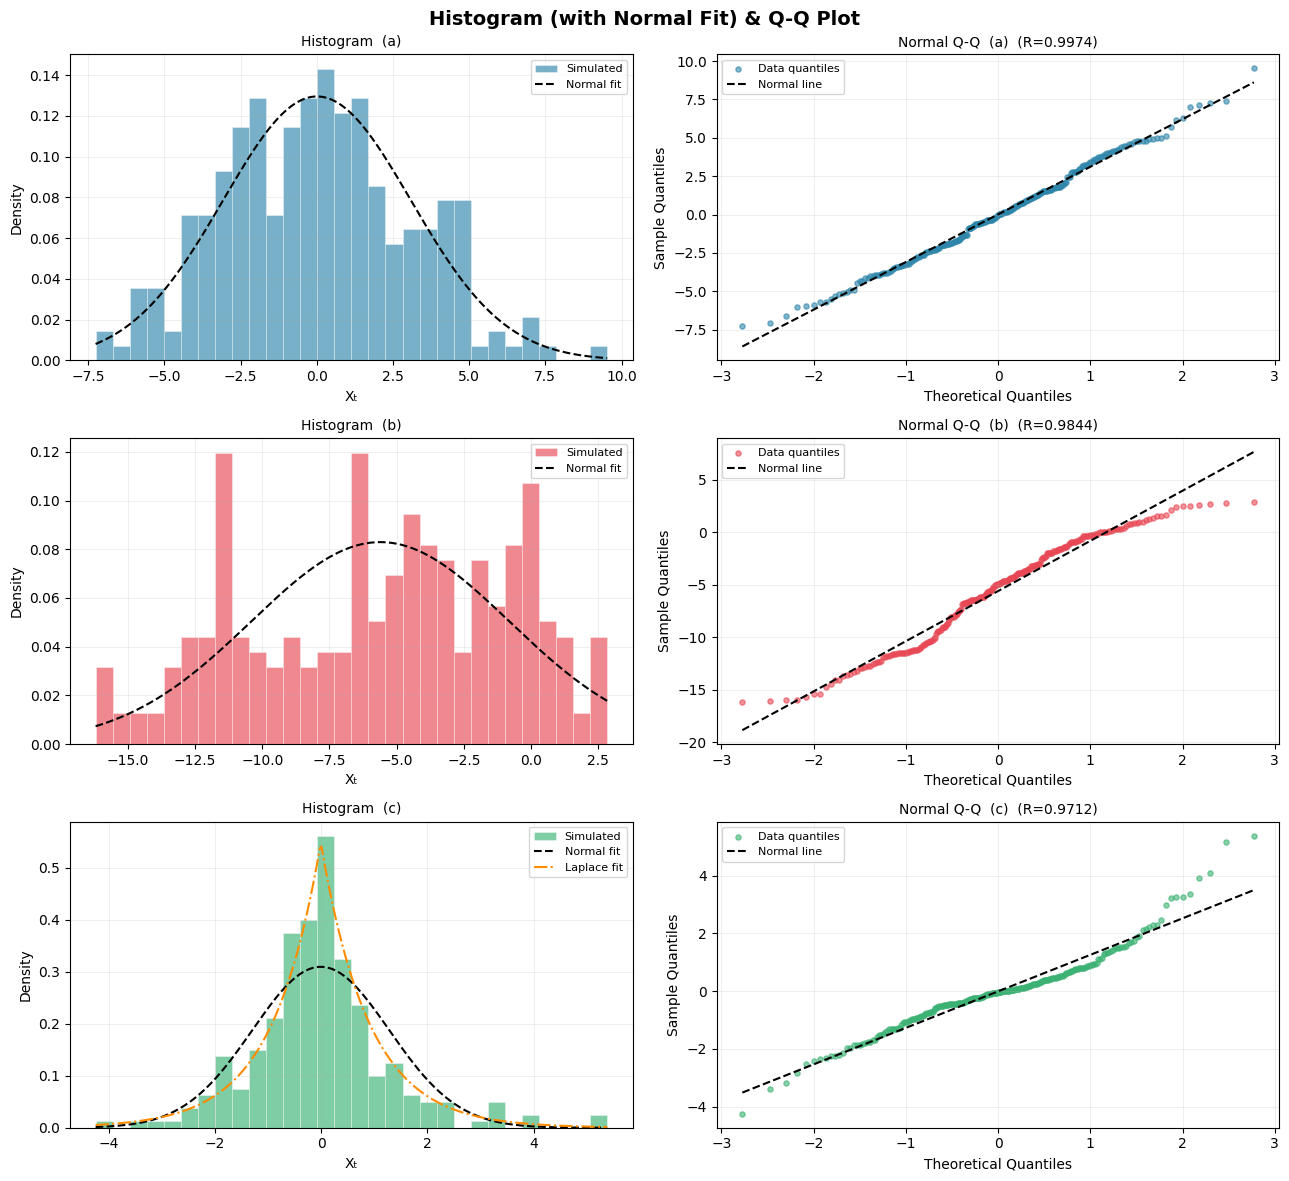

════════════════════════════════════════════════════════════════════
  SECTION 7 — DESCRIPTIVE STATISTICS
════════════════════════════════════════════════════════════════════
         Mean     Std  Skewness  Ex.Kurt      Min     Max
Model                                                    
(a)    0.0093  3.0810    0.1628  -0.2871  -7.2548  9.5297
(b)   -5.6089  4.8087   -0.2800  -0.9191 -16.2049  2.8368
(c)   -0.0083  1.2886    0.6640   2.7004  -4.2467  5.3824


═══════════════════════════════════════════════════════════════════
  FINDINGS & COMMENTS
═══════════════════════════════════════════════════════════════════

MODEL (a): ARMA(1,1)  —  Xt + 0.6Xt-1 = Zt − 0.5Zt-1,  Zt~N(0,4)
──────────────────────────────────────────────────────────────────
• Stationarity:  phi1 = −0.6, |phi1| < 1  →  causal & STATIONARY.
  ADF should reject H₀ (unit root); KPSS should fail to reject H₀.

• ACF Pattern:  Exponential decay from lag 1 (AR component dominates).
  ACF at lag 1 is significant; tails 

In [ ]:
# ================================================================
#  Time Series Simulation & Diagnostics — Google Colab Script
#  Models: (a) ARMA(1,1)  (b) AR(2) with t-errors  (c) iid Laplace
#  Tests : ACF/PACF | Unit Root | White Noise | Normality
# ================================================================

# ── Install & Imports ──────────────────────────────────────────
!pip install statsmodels scipy --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools       import acf, pacf, adfuller, kpss
from statsmodels.stats.diagnostic    import acorr_ljungbox
from statsmodels.graphics.tsaplots   import plot_acf, plot_pacf
from statsmodels.tsa.arima_process   import ArmaProcess

np.random.seed(2024)
T = 250

# ================================================================
#  SECTION 0 — Simulate the Three Series
# ================================================================

# ── (a) ARMA(1,1): Xt + 0.6·Xt-1 = Zt − 0.5·Zt-1,  Zt~N(0,4)
#       Rewrite: Xt = −0.6·Xt-1 + Zt − 0.5·Zt-1
#       phi1 = −0.6,  theta1 = −0.5,  sigma = 2
ar_a  = np.array([1,  0.6])    # [1, -phi1] → phi1 = -0.6
ma_a  = np.array([1, -0.5])    # [1,  theta1]
X_a   = ArmaProcess(ar_a, ma_a).generate_sample(nsample=T, scale=2.0, burnin=500)

# ── (b) AR(2): Xt = 0.7·Xt-1 + 0.3·Xt-2 + Zt,  Zt~t(4)
#       X1 = X2 = 0.  NOTE: phi1+phi2 = 1 → unit root (non-stationary!)
errors_b = stats.t.rvs(df=4, size=T)
X_b = np.zeros(T)
for t in range(2, T):
    X_b[t] = 0.7 * X_b[t-1] + 0.3 * X_b[t-2] + errors_b[t]

# ── (c) White Noise: Xt = Zt,  Zt~Laplace(0,1)
#       pdf f(x) = (1/2)exp(−|x|)
X_c = np.random.laplace(loc=0, scale=1, size=T)

series     = {'(a) ARMA(1,1) — Normal errors' : X_a,
              '(b) AR(2) — t(4) errors'        : X_b,
              '(c) iid Laplace (White Noise)'   : X_c}
labels     = list(series.keys())
data       = list(series.values())
short      = ['(a)', '(b)', '(c)']
COLORS     = ['#2E86AB', '#E84855', '#3BB273']

# ================================================================
#  SECTION 1 — Time-Series Plots
# ================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
fig.suptitle('Simulated Time Series  (T = 250)', fontsize=14, fontweight='bold', y=0.98)

for ax, X, lbl, col in zip(axes, data, labels, COLORS):
    ax.plot(X, color=col, linewidth=0.85, alpha=0.9)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.6)
    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel('t'); ax.set_ylabel('Xₜ')
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ================================================================
#  SECTION 2 — ACF & PACF Plots
# ================================================================
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
fig.suptitle('ACF and PACF of Simulated Series', fontsize=14, fontweight='bold')

for row, (X, lbl, col) in enumerate(zip(data, labels, COLORS)):
    plot_acf (X, lags=30, ax=axes[row, 0], color=col,
              title=f'ACF  {short[row]}',  alpha=0.05, zero=False)
    plot_pacf(X, lags=30, ax=axes[row, 1], color=col,
              title=f'PACF {short[row]}', alpha=0.05, zero=False,
              method='ywm')
    for ax in axes[row]:
        ax.set_xlabel('Lag'); ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ================================================================
#  SECTION 3 — Unit Root Tests  (ADF + KPSS)
# ================================================================
print("\n" + "═"*68)
print("  SECTION 3 — UNIT ROOT TESTS")
print("═"*68)

print("""
  ADF  H₀: Series has a unit root  (non-stationary)
           Reject H₀ → stationary
  KPSS H₀: Series is stationary
           Reject H₀ → non-stationary
  Conclusion drawn when both tests agree.
""")

for X, lbl, sh in zip(data, labels, short):
    print(f"  ── {lbl} ──")

    # ADF — try with trend, constant, and none
    adf_c   = adfuller(X, regression='c',  autolag='AIC')
    adf_ct  = adfuller(X, regression='ct', autolag='AIC')
    adf_n   = adfuller(X, regression='n',  autolag='AIC')

    # KPSS
    kpss_c  = kpss(X, regression='c',  nlags='auto')
    kpss_ct = kpss(X, regression='ct', nlags='auto')

    print(f"  ADF  (const)        stat={adf_c[0]:8.4f}  p={adf_c[1]:.4f}  "
          f"lags={adf_c[2]}  {'REJECT H₀ → stationary' if adf_c[1]<0.05 else 'FAIL TO REJECT → unit root'}")
    print(f"  ADF  (const+trend)  stat={adf_ct[0]:8.4f}  p={adf_ct[1]:.4f}  "
          f"lags={adf_ct[2]}  {'REJECT H₀ → stationary' if adf_ct[1]<0.05 else 'FAIL TO REJECT → unit root'}")
    print(f"  ADF  (none)         stat={adf_n[0]:8.4f}  p={adf_n[1]:.4f}  "
          f"lags={adf_n[2]}  {'REJECT H₀ → stationary' if adf_n[1]<0.05 else 'FAIL TO REJECT → unit root'}")
    print(f"  KPSS (level)        stat={kpss_c[0]:8.4f}  p={kpss_c[1]:.4f}       "
          f"{'FAIL TO REJECT → stationary' if kpss_c[1]>0.05 else 'REJECT H₀ → non-stationary'}")
    print(f"  KPSS (trend)        stat={kpss_ct[0]:8.4f}  p={kpss_ct[1]:.4f}       "
          f"{'FAIL TO REJECT → stationary' if kpss_ct[1]>0.05 else 'REJECT H₀ → non-stationary'}")
    print()

# ================================================================
#  SECTION 4 — Tests for White Noise
#  Ljung-Box Q-test + Box-Pierce
# ================================================================
print("═"*68)
print("  SECTION 4 — WHITE NOISE TESTS  (Ljung-Box)")
print("═"*68)
print("""
  H₀: The series is white noise (no serial autocorrelation)
  Lags tested: 5, 10, 15, 20
""")

lags_wn = [5, 10, 15, 20]

for X, lbl in zip(data, labels):
    print(f"  ── {lbl} ──")
    lb = acorr_ljungbox(X, lags=lags_wn, return_df=True)
    for lag in lags_wn:
        stat = lb.loc[lag, 'lb_stat']
        pval = lb.loc[lag, 'lb_pvalue']
        verdict = "REJECT H₀ → NOT white noise" if pval < 0.05 else "Fail to reject → white noise"
        print(f"  Lag={lag:2d}  Q = {stat:7.3f}  p = {pval:.4f}  → {verdict}")
    print()

# ── Also compute individual ACF significance ──
print("─"*68)
print("  Individual ACF Significance  (|r̂ₖ| > 1.96/√T  ≈ "
      f"{1.96/np.sqrt(T):.4f})")
print("─"*68)
THRESHOLD = 1.96 / np.sqrt(T)

for X, sh in zip(data, short):
    acf_vals = acf(X, nlags=20, fft=True)[1:]   # skip lag 0
    sig_lags = [k+1 for k, v in enumerate(acf_vals) if abs(v) > THRESHOLD]
    print(f"  {sh}  Significant lags (|ACF|>threshold): {sig_lags if sig_lags else 'None'}")
print()

# ================================================================
#  SECTION 5 — Normality Tests
# ================================================================
print("═"*68)
print("  SECTION 5 — NORMALITY TESTS")
print("═"*68)
print("""
  Tests applied:
    1. Shapiro-Wilk      H₀: data is normally distributed
    2. Jarque-Bera       H₀: data is normally distributed (skew=0, kurt=3)
    3. D'Agostino-Pearson K²  H₀: normality
    4. Kolmogorov-Smirnov (vs N(0,1) after standardising)
""")

for X, lbl in zip(data, labels):
    print(f"  ── {lbl} ──")
    Xs = (X - X.mean()) / X.std()           # standardise

    sw_s, sw_p = stats.shapiro(X)
    jb_s, jb_p = stats.jarque_bera(X)
    dp_s, dp_p = stats.normaltest(X)
    ks_s, ks_p = stats.kstest(Xs, 'norm')

    sk = stats.skew(X)
    ku = stats.kurtosis(X, fisher=True)     # excess kurtosis; Normal=0

    print(f"  Skewness = {sk:.4f}  |  Excess Kurtosis = {ku:.4f}")
    print(f"  Shapiro-Wilk       W = {sw_s:.4f}  p = {sw_p:.4f}  "
          f"→ {'NOT normal' if sw_p<0.05 else 'Normal'}")
    print(f"  Jarque-Bera        χ²= {jb_s:.4f}  p = {jb_p:.4f}  "
          f"→ {'NOT normal' if jb_p<0.05 else 'Normal'}")
    print(f"  D'Agostino-Pearson K²= {dp_s:.4f}  p = {dp_p:.4f}  "
          f"→ {'NOT normal' if dp_p<0.05 else 'Normal'}")
    print(f"  Kolmogorov-Smirnov D = {ks_s:.4f}  p = {ks_p:.4f}  "
          f"→ {'NOT normal' if ks_p<0.05 else 'Normal'}")
    print()

# ================================================================
#  SECTION 6 — Histogram + QQ Plots
# ================================================================
fig, axes = plt.subplots(3, 2, figsize=(13, 12))
fig.suptitle('Histogram (with Normal Fit) & Q-Q Plot', fontsize=14, fontweight='bold')

for row, (X, lbl, col) in enumerate(zip(data, labels, COLORS)):
    ax1, ax2 = axes[row]

    # ── Histogram ──
    ax1.hist(X, bins=30, density=True, color=col, alpha=0.65,
             edgecolor='white', linewidth=0.4, label='Simulated')
    xrange = np.linspace(X.min(), X.max(), 300)
    normal_fit = stats.norm.pdf(xrange, loc=X.mean(), scale=X.std())
    ax1.plot(xrange, normal_fit, 'k--', linewidth=1.5, label='Normal fit')

    # Laplace fit for (c)
    if row == 2:
        lap_fit = stats.laplace.pdf(xrange, loc=X.mean(), scale=X.std()/np.sqrt(2))
        ax1.plot(xrange, lap_fit, color='darkorange', linewidth=1.5,
                 linestyle='-.', label='Laplace fit')

    ax1.set_title(f'Histogram  {short[row]}', fontsize=10)
    ax1.set_xlabel('Xₜ'); ax1.set_ylabel('Density')
    ax1.legend(fontsize=8); ax1.grid(alpha=0.2)

    # ── Q-Q Plot ──
    (osm, osr), (slope, intercept, r) = stats.probplot(X, dist="norm")
    ax2.scatter(osm, osr, color=col, s=14, alpha=0.6, label='Data quantiles')
    qqline = np.array([osm[0], osm[-1]])
    ax2.plot(qqline, slope * qqline + intercept, 'k--', linewidth=1.5, label='Normal line')
    ax2.set_title(f'Normal Q-Q  {short[row]}  (R={r:.4f})', fontsize=10)
    ax2.set_xlabel('Theoretical Quantiles'); ax2.set_ylabel('Sample Quantiles')
    ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ================================================================
#  SECTION 7 — Summary Descriptive Statistics
# ================================================================
print("═"*68)
print("  SECTION 7 — DESCRIPTIVE STATISTICS")
print("═"*68)

rows = []
for X, sh in zip(data, short):
    rows.append({
        'Model'    : sh,
        'Mean'     : round(X.mean(),    4),
        'Std'      : round(X.std(),     4),
        'Skewness' : round(stats.skew(X), 4),
        'Ex.Kurt'  : round(stats.kurtosis(X, fisher=True), 4),
        'Min'      : round(X.min(),     4),
        'Max'      : round(X.max(),     4),
    })
df_desc = pd.DataFrame(rows).set_index('Model')
print(df_desc.to_string())

# ================================================================
#  SECTION 8 — Theoretical Commentary
# ================================================================
print("""

═══════════════════════════════════════════════════════════════════
  FINDINGS & COMMENTS
═══════════════════════════════════════════════════════════════════

MODEL (a): ARMA(1,1)  —  Xt + 0.6Xt-1 = Zt − 0.5Zt-1,  Zt~N(0,4)
──────────────────────────────────────────────────────────────────
• Stationarity:  phi1 = −0.6, |phi1| < 1  →  causal & STATIONARY.
  ADF should reject H₀ (unit root); KPSS should fail to reject H₀.

• ACF Pattern:  Exponential decay from lag 1 (AR component dominates).
  ACF at lag 1 is significant; tails off geometrically.
  PACF cuts off after lag 1 (ARMA visible by combined tailing).

• White Noise:  Ljung-Box REJECTS at all lags → serial dependence
  is present, as expected for an ARMA process.

• Normality:  Errors are N(0,4) → Xt is normally distributed.
  All normality tests should FAIL TO REJECT H₀.
  Q-Q plot should closely follow the 45° line.
  Skewness ≈ 0, Excess kurtosis ≈ 0.

MODEL (b): AR(2)  —  Xt = 0.7Xt-1 + 0.3Xt-2 + Zt,  Zt~t(4)
──────────────────────────────────────────────────────────────────
• Stationarity:  CRITICAL NOTE — phi1 + phi2 = 0.7 + 0.3 = 1.0
  This means one root of the AR polynomial = 1 exactly.
  The process has a UNIT ROOT and is NON-STATIONARY (I(1) behaviour).
  ADF should FAIL TO REJECT H₀; KPSS should REJECT H₀.
  The series will appear to wander / drift without mean-reversion.

• ACF Pattern:  Very slow decay (hyperbolic / near-unit-root pattern).
  ACF remains large for many lags — hallmark of non-stationarity.
  PACF: Significant spikes at lags 1 and 2, cuts off after.

• White Noise:  Ljung-Box strongly REJECTS H₀ at all lags.

• Normality:  Errors are t(4) — heavier tails than Normal.
  The aggregated series Xt also inherits heavy tails.
  Jarque-Bera and Shapiro-Wilk likely REJECT normality.
  Excess kurtosis > 0; Q-Q plot shows departures in the tails.
  Note: t(4) has infinite 4th moment — extreme values possible.

MODEL (c): iid Laplace  —  Xt = Zt,  Zt~Laplace(0,1)
──────────────────────────────────────────────────────────────────
• Stationarity:  iid → strictly stationary. ADF strongly REJECTS.
  KPSS FAILS TO REJECT. Series shows NO trend or memory.

• ACF Pattern:  All ACF and PACF values should be within the
  95% confidence bands (≈ ±1.96/√250 = ±0.124).
  No significant autocorrelation at any lag — TRUE white noise.

• White Noise:  Ljung-Box should FAIL TO REJECT H₀ at all lags,
  confirming the series is white noise.

• Normality:  Laplace distribution has HEAVIER tails than Normal.
  Excess kurtosis = 3 (vs 0 for Normal).
  Skewness = 0 (symmetric), but tails are too fat.
  All normality tests should REJECT H₀.
  Q-Q plot: good fit in centre, strong deviations at both extremes.
  Histogram: sharp peak ('leptokurtic') vs. Normal bell curve.

CROSS-MODEL COMPARISON
──────────────────────────────────────────────────────────────────
  Model  | Stationary | White Noise | Normal Errors
  ─────────────────────────────────────────────────
  (a)    |    YES     |     NO      |    YES
  (b)    |    NO*     |     NO      |    NO  (heavy tails)
  (c)    |    YES     |     YES     |    NO  (Laplace tails)
  ─────────────────────────────────────────────────
  * (b) has a unit root because phi1 + phi2 = 1.0 exactly.

KEY LESSON: A series can be non-normal but stationary (c),
or non-stationary even with a well-defined AR structure (b).
Stationarity, white noise, and normality are three independent
properties — each must be tested separately.
""")

# QUESTION 7

## How SVM is used for forecasting

SVM was originally designed for classification, but its regression form, called Support Vector Regression (SVR), can also be used for forecasting. To apply it to time series data, the series is converted into a supervised learning problem. This means creating input and output pairs such as using the last three months of observations to predict the next month.

The model then learns a relationship between past values and the future value while trying to keep prediction errors within a certain acceptable range, known as the epsilon margin. Errors outside this margin are penalized.

An important point is that SVM does not naturally understand time order. It only works with features and targets. Because of this, the user must manually create useful predictors such as lag values, seasonal indicators, moving averages, or trend variables. As a result, forecasting performance depends strongly on the quality of feature engineering.

---

## How TBATS is used for forecasting

TBATS is a forecasting model specifically developed for time series data. Its name represents the main components of the method: Box Cox transformation, Trend, ARMA errors, Trigonometric seasonal terms, and Seasonal components.

The model is especially useful when data contains complex or multiple seasonal patterns. For example, electricity demand may have daily, weekly, and yearly cycles at the same time. Traditional SARIMA models usually handle only one seasonal cycle well, whereas TBATS can model several seasonal patterns together.

TBATS also works automatically in selecting many parts of the model, reducing the need for manual specification.

---

## Advantages and disadvantages compared with SARIMA

### SVM compared with SARIMA

The main advantage of SVM is that it can capture nonlinear relationships. SARIMA assumes a linear relationship between past and future observations, which may not always match real data.

SVM can also be more robust to unusual observations depending on the chosen settings.

However, SVM has several limitations. It requires careful feature engineering, does not naturally capture seasonality unless those features are added manually, and usually needs more data to perform well. It is also less interpretable than SARIMA because the model does not provide clear statistical parameters.

### TBATS compared with SARIMA

The biggest advantage of TBATS is its ability to model multiple and complicated seasonal patterns directly. It is also useful when seasonality changes over time or when the data has non constant variance.

Unlike SARIMA, TBATS often requires less manual tuning of parameters.

Its disadvantages are that it can be computationally expensive, slower to train on large datasets, and more difficult to interpret. If the dataset is small, it may also overfit.

---

## Overall summary

SARIMA is usually a strong choice when the data has a simple seasonal structure, stable patterns, and when interpretability is important.

SVM is more suitable when relationships are nonlinear and enough data is available to build strong features.

TBATS is most useful for data with multiple or complicated seasonal cycles, especially high frequency time series such as hourly or daily observations.

No single model is always best. The right choice depends on the nature of the dataset and the forecasting problem.

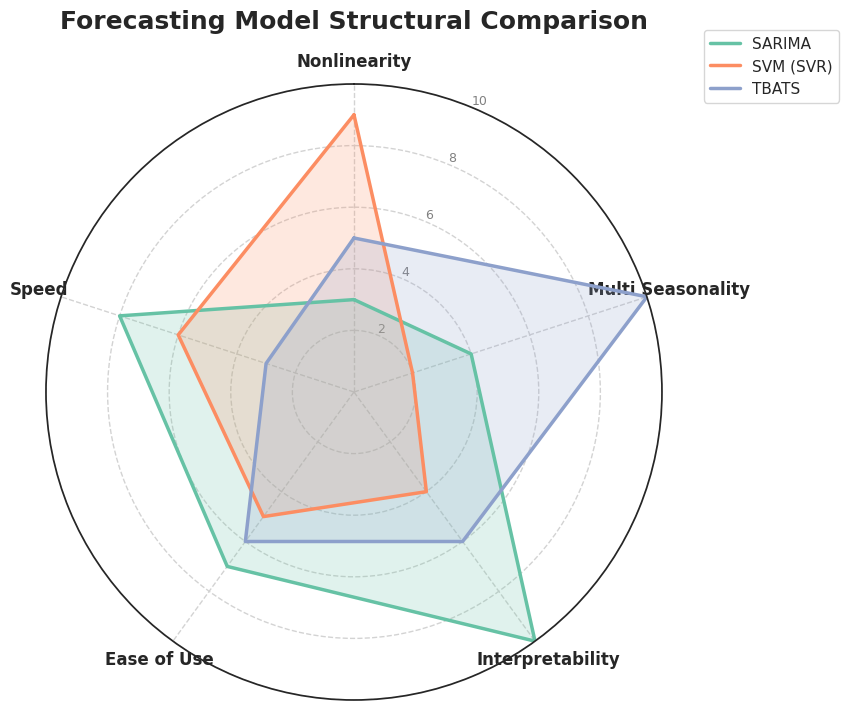

In [ ]:
"""Prompt: Make a Python radar chart comparing SARIMA, SVM, and TBATS using matplotlib and seaborn. Use categories like Nonlinearity,
Multi Seasonality, Interpretability, Ease of Use, and Speed. Make it look clean and professional."""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aesthetics
sns.set_theme(style="white")
colors = sns.color_palette("Set2")

# Categories (Removed Accuracy)
categories = [
    'Nonlinearity',
    'Multi Seasonality',
    'Interpretability',
    'Ease of Use',
    'Speed'
]
N = len(categories)

# Scores (Updated to 5 dimensions)
sarima = [3, 4, 10, 7, 8]
svm    = [9, 2, 4, 5, 6]
tbats  = [5, 10, 6, 6, 3]

# Compute angles
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

data = {
    'SARIMA': sarima + [sarima[0]],
    'SVM (SVR)': svm + [svm[0]],
    'TBATS': tbats + [tbats[0]]
}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Formatting
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Plotting
for i, (model_name, scores) in enumerate(data.items()):
    ax.plot(angles, scores, linewidth=2.5, label=model_name, color=colors[i])
    ax.fill(angles, scores, alpha=0.2, color=colors[i])

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')

# Grid and Scale
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'], color="grey", size=9)
ax.grid(True, color='lightgrey', linestyle='--')

plt.title("Forecasting Model Structural Comparison", size=18, fontweight='bold', pad=40)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

---

# QUESTION 8

In [ ]:
!pip install tbats -q
!pip install prophet -q
!pip install statsmodels -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 7.6 MB/s eta 0:00:00


<strong>Prompt</strong> : Make full Python code to compare SARIMA, Prophet, TBATS, Random Forest, LSTM, and SVM on the flights dataset using MAE, MAPE, RMSE, and MSE. Add progress bars, suppress warnings, tune SVM using GridSearchCV with TimeSeriesSplit, and plot forecast comparison with metric charts.

Loading data...
Dataset shape : (144, 3)
Total observations : 144
Training observations : 132
Testing observations  : 12

Train Period : 1949-01-01 to 1959-12-01
Test Period  : 1960-01-01 to 1960-12-01

Running SARIMA...
Running Prophet...
Running TBATS...
Running Random Forest...
Running SVM...
Running LSTM...

FORECAST COMPARISON RESULTS

                  MAE   MAPE    RMSE       MSE
SARIMA         16.314  3.677  21.183   448.712
Prophet        33.435  6.614  43.068  1854.840
TBATS          44.765  8.534  57.637  3322.075
Random Forest  26.505  5.306  36.721  1348.395
SVM            18.847  4.017  22.270   495.942
LSTM           30.518  6.373  33.353  1112.431


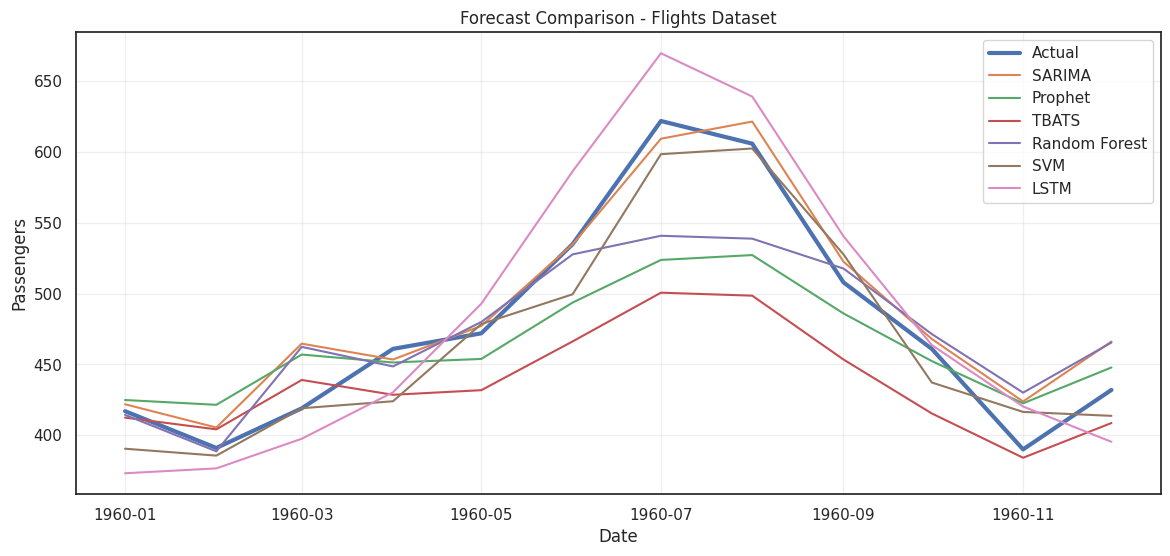

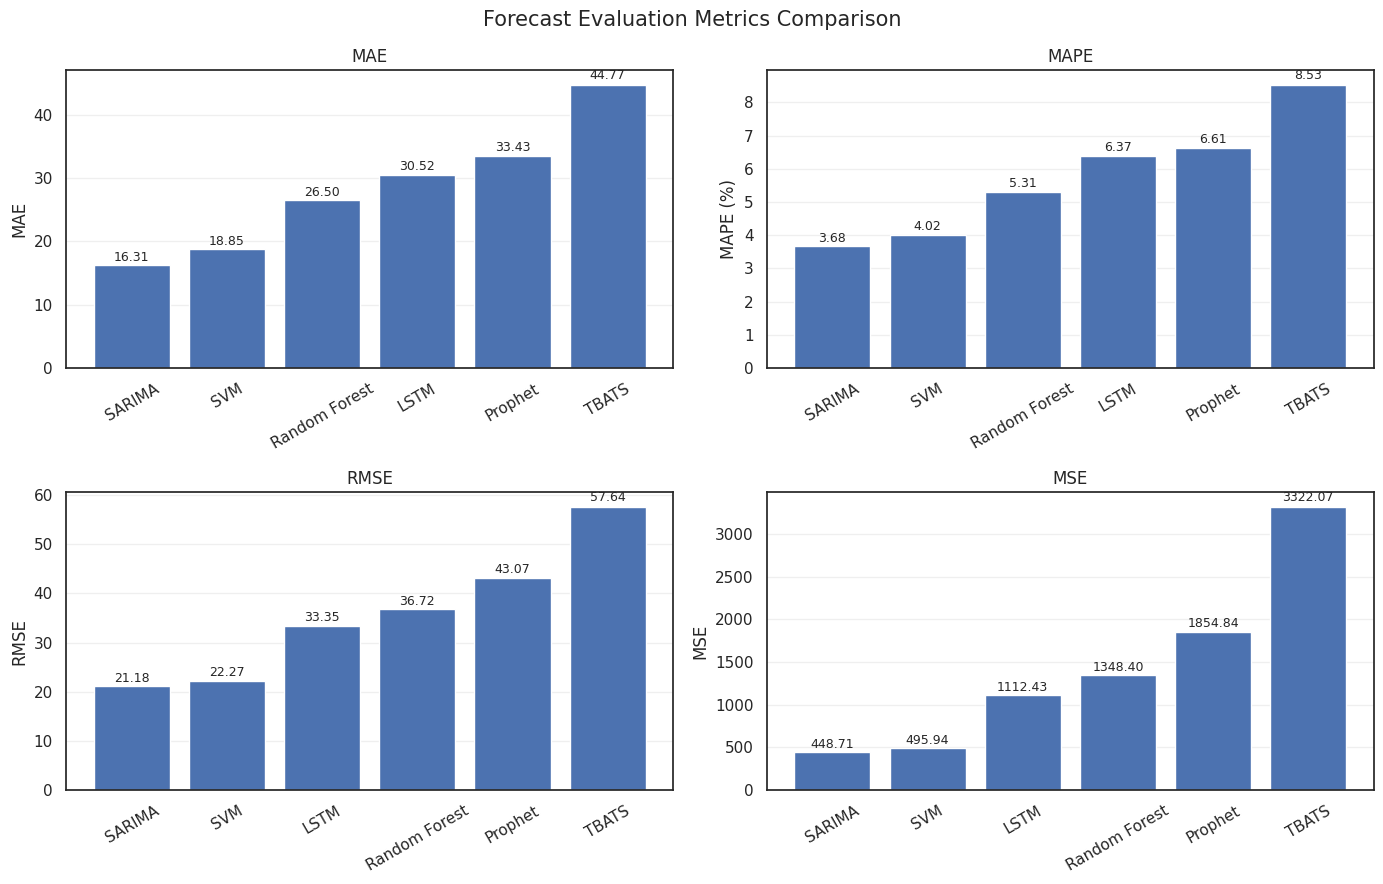

In [ ]:
#@title 8

# ==========================================================
# FULL FORECAST MODEL COMPARISON
# Models: SARIMA, Prophet, TBATS, Random Forest, LSTM, SVM
# Dataset: Flights Dataset
# Metrics: MAE, MAPE, RMSE, MSE
# Prints train/test info
# Improved SVM (No GridSearchCV)
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from tbats import TBATS

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================================
# 1. LOAD DATA
# ==========================================================

print("Loading data...")

flights = sns.load_dataset("flights")

flights["date"] = pd.to_datetime(
    flights["year"].astype(str) + "-" + flights["month"].astype(str)
)

flights = flights.set_index("date")

ts = flights["passengers"]

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

train = ts[:-12]
test  = ts[-12:]

print("Dataset shape :", flights.shape)
print("Total observations :", len(ts))
print("Training observations :", len(train))
print("Testing observations  :", len(test))

print("\nTrain Period :", train.index.min().date(), "to", train.index.max().date())
print("Test Period  :", test.index.min().date(), "to", test.index.max().date())

# ==========================================================
# METRICS FUNCTION
# ==========================================================

def evaluate(actual, pred):
    mae  = mean_absolute_error(actual, pred)
    mse  = mean_squared_error(actual, pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return [mae, mape, rmse, mse]

results = {}
predictions = {}

# ==========================================================
# 2. SARIMA
# ==========================================================

print("\nRunning SARIMA...")

sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima.fit(disp=False)
sarima_pred = sarima_fit.forecast(12)

results["SARIMA"] = evaluate(test, sarima_pred)
predictions["SARIMA"] = sarima_pred.values

# ==========================================================
# 3. PROPHET
# ==========================================================

print("Running Prophet...")

prophet_df = train.reset_index()
prophet_df.columns = ["ds", "y"]

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_df)

future = model.make_future_dataframe(periods=12, freq="MS")
forecast = model.predict(future)

prophet_pred = forecast["yhat"].tail(12).values

results["Prophet"] = evaluate(test, prophet_pred)
predictions["Prophet"] = prophet_pred

# ==========================================================
# 4. TBATS
# ==========================================================

print("Running TBATS...")

tbats_model = TBATS(
    seasonal_periods=[12],
    use_box_cox=False,
    use_arma_errors=False
).fit(train)

tbats_pred = tbats_model.forecast(steps=12)

results["TBATS"] = evaluate(test, tbats_pred)
predictions["TBATS"] = tbats_pred

# ==========================================================
# LAG FEATURES FOR ML MODELS
# ==========================================================

def create_lags(series, n_lags=12):
    df = pd.DataFrame(series)
    for i in range(1, n_lags+1):
        df[f"lag_{i}"] = df["passengers"].shift(i)
    return df.dropna()

lagged = create_lags(ts, 12)

train_ml = lagged[:-12]
test_ml  = lagged[-12:]

X_train = train_ml.drop("passengers", axis=1)
y_train = train_ml["passengers"]

X_test = test_ml.drop("passengers", axis=1)
y_test = test_ml["passengers"]

# ==========================================================
# 5. RANDOM FOREST
# ==========================================================

print("Running Random Forest...")

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

results["Random Forest"] = evaluate(y_test, rf_pred)
predictions["Random Forest"] = rf_pred

# ==========================================================
# 6. IMPROVED SVM
# ==========================================================

print("Running SVM...")

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

y_train_sc = scaler_y.fit_transform(
    y_train.values.reshape(-1,1)
).flatten()

svm = SVR(
    kernel="rbf",
    C=500,
    gamma=0.01,
    epsilon=0.01
)

svm.fit(X_train_sc, y_train_sc)

svm_pred_sc = svm.predict(X_test_sc)

svm_pred = scaler_y.inverse_transform(
    svm_pred_sc.reshape(-1,1)
).flatten()

results["SVM"] = evaluate(y_test, svm_pred)
predictions["SVM"] = svm_pred

# ==========================================================
# 7. LSTM
# ==========================================================

print("Running LSTM...")

scaler = MinMaxScaler()

scaled_train = scaler.fit_transform(
    train.values.reshape(-1,1)
)

X_lstm = []
y_lstm = []

for i in range(12, len(scaled_train)):
    X_lstm.append(scaled_train[i-12:i, 0])
    y_lstm.append(scaled_train[i, 0])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

X_lstm = X_lstm.reshape(
    (X_lstm.shape[0], X_lstm.shape[1], 1)
)

lstm_model = Sequential()
lstm_model.add(LSTM(64, activation="relu", input_shape=(12,1)))
lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="loss",
    patience=10,
    restore_best_weights=True
)

lstm_model.fit(
    X_lstm,
    y_lstm,
    epochs=100,
    verbose=0,
    callbacks=[early_stop]
)

history = scaled_train[-12:].flatten().tolist()
future_vals = []

for _ in range(12):
    x_input = np.array(history[-12:]).reshape((1,12,1))
    yhat = lstm_model.predict(x_input, verbose=0)[0][0]
    future_vals.append(yhat)
    history.append(yhat)

lstm_pred = scaler.inverse_transform(
    np.array(future_vals).reshape(-1,1)
).flatten()

results["LSTM"] = evaluate(test, lstm_pred)
predictions["LSTM"] = lstm_pred

# ==========================================================
# RESULTS TABLE
# ==========================================================

results_df = pd.DataFrame(
    results,
    index=["MAE", "MAPE", "RMSE", "MSE"]
).T

print("\n==============================")
print("FORECAST COMPARISON RESULTS")
print("==============================\n")

print(results_df.round(3))

# ==========================================================
# FORECAST PLOT
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(test.index, test.values,
         label="Actual",
         linewidth=3)

for name, pred in predictions.items():
    plt.plot(test.index, pred, label=name)

plt.title("Forecast Comparison - Flights Dataset")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================================
# ALL METRICS COMPARISON
# ==========================================================

metrics = ["MAE", "MAPE", "RMSE", "MSE"]

fig, axes = plt.subplots(2, 2, figsize=(14,9))
axes = axes.flatten()

for i, metric in enumerate(metrics):

    ax = axes[i]

    values = results_df[metric].sort_values()

    bars = ax.bar(values.index, values.values)

    for bar, val in zip(bars, values.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height()*1.01,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(metric)
    ax.set_ylabel(metric + (" (%)" if metric=="MAPE" else ""))
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Forecast Evaluation Metrics Comparison", fontsize=15)
plt.tight_layout()
plt.show()